# Yellow Taxi Sample EDA

This notebook is the exploratory data analysis for the Yellow Taxi portion of the NYC congestion pricing project.

The goal is to understand whether the first-step cleaned Yellow Taxi sample is usable, identify variables that need special handling, and decide what should be carried into later feature engineering and full-data aggregation.

**Primary data used here:** `data/processed/samples/yellow_taxi_trip_level_sample_20k_representative.csv`

This file is intended to represent the Yellow Taxi sample after the first-step conservative cleaning. Additional fields as outcome of the EDA process are created inside this notebook rather than treated as official cleaning outputs.

**Optional helper-rich copy:** `data/processed/samples/yellow_taxi_trip_level_sample_20k_eda_features.csv`

This file contains the same rows plus convenience flags used during EDA. It should not be confused with the first-step cleaned sample.

**Sampling note:** this is a representative sample stratified by `year x month`. For aggregate percentages or means, this notebook uses `sample_weight` when possible.

## 0. Data Layers, Policy Timing, and Analysis Rules

This notebook separates two different issues: **what data layer we are using** and **how policy-facing metrics should be interpreted**.

**Data layers:**

1. **First-step cleaned sample**: rows retained after the team's conservative validity filters. This is the main input dataset for this EDA.
2. **EDA helper fields**: labels, buckets, and flags created inside this notebook to make patterns easier to inspect. These are diagnostic fields, not automatically final feature-engineering decisions.

**Analysis rules:**

1. **Policy timing rule**: the CBD congestion fee is a post-policy variable. A 2024 CBD fee or burden average is not substantively meaningful because the policy had not started.
2. **Analysis inclusion rule**: different questions use different subsets of the retained rows. For example, passenger-burden analysis should focus on standard paid trips, while distance-based analysis should exclude zero-distance rows.

The first-step cleaned sample should therefore not be treated as if it already contains every final analysis decision.

**Time frame used in this notebook:**

- **Pre-policy comparison window:** February-June 2024.
- **Post-policy window:** February-June 2025.
- **January 2025 is excluded** because the CBD congestion pricing policy began on January 5, 2025, so January is a transition month rather than a clean pre/post month.
- Matching the same calendar months reduces seasonality problems. For example, February 2024 is compared with February 2025, not with a different season.

**How to interpret policy variables:**

- `cbd_congestion_fee` and `charged_cbd_flag` are policy-exposure variables. 2024 should be used only as a sanity check that the CBD fee is zero before the policy.
- `relative_cbd_burden = cbd_congestion_fee / passenger_cost_pretip` should be interpreted only for **post-policy charged trips**, because pre-policy trips mechanically have zero CBD fee.
- Passenger cost, distance, duration, payment composition, and trip volume can be compared pre/post, but they should generally be reported by month rather than as one overall 2024+2025 average.

**Team first-step cleaning rules used before sampling:**

- parse pickup/dropoff timestamps;
- keep rows with `dropoff_datetime > pickup_datetime`;
- keep rows whose pickup year/month match the source file;
- require non-missing pickup and dropoff zone IDs;
- require nonnegative trip distance;
- require positive trip duration;
- require non-missing, nonnegative `cbd_congestion_fee` after filling pre-policy 2024 missing values with 0;
- require positive `passenger_cost_pretip`.

**Main Yellow Taxi analysis rules suggested by this EDA:**

- main passenger-burden analysis should start with standard paid trips: `payment_type` 1 and 2, or credit card and cash;
- Flex Fare rows should be flagged and analyzed separately because their component reporting is structurally different;
- no charge, dispute, unknown, and voided trips should be excluded from main burden analysis and used only for sensitivity checks;
- zero-distance trips should be retained as flagged records in the broad cleaned sample, but excluded from distance-, speed-, and fare-per-mile analyses;
- final policy-facing summaries should be checked on full-data monthly/zone aggregates, not only on this 20K sample.

## 1. Setup

This section loads the 20K representative Yellow Taxi sample and defines small helper functions for weighted summaries. Because the sample is stratified by month, weighted summaries are safer than raw row percentages when we want to describe the underlying cleaned Yellow Taxi data.

The cells below also display the sample structure and time window coverage (February–June 2024 and February–June 2025).

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

CWD = Path.cwd().resolve()
SAMPLE_REL_PATH = Path("data/processed/samples/yellow_taxi_trip_level_sample_20k_representative.csv")

for candidate in [CWD, CWD.parent]:
    if (candidate / SAMPLE_REL_PATH).exists():
        REPO_ROOT = candidate
        break
else:
    raise FileNotFoundError(
        "Could not find yellow_taxi_trip_level_sample_20k_representative.csv "
        "from the current notebook working directory or its parent."
    )

SAMPLE_PATH = REPO_ROOT / SAMPLE_REL_PATH

sample = pd.read_csv(
    SAMPLE_PATH,
    parse_dates=["pickup_datetime", "dropoff_datetime"],
)

In [2]:
# EDA helper fields created from the first-step cleaned sample.
# These are not additional row-dropping cleaning rules.
YELLOW_PAYMENT_LABELS = {
    0: "Flex Fare",
    1: "Credit card",
    2: "Cash",
    3: "No charge",
    4: "Dispute",
    5: "Unknown",
    6: "Voided trip",
}

sample["payment_type"] = pd.to_numeric(sample["payment_type"], errors="coerce")
sample["yellow_payment_type_label"] = sample["payment_type"].map(YELLOW_PAYMENT_LABELS)
sample["yellow_card_or_cash_flag"] = sample["payment_type"].isin([1, 2])
sample["yellow_no_charge_dispute_void_flag"] = sample["payment_type"].isin([3, 4, 6])
sample["yellow_payment_unknown_flag"] = sample["payment_type"] == 5
sample["yellow_payment_review_flag"] = sample["payment_type"].isin([0, 3, 4, 5, 6])
sample["flex_fare_flag"] = sample["payment_type"] == 0
sample["yellow_disputed_flag"] = sample["payment_type"].isin([3, 4, 5, 6])  # No charge, Dispute, Unknown, Voided
sample["standard_paid_flag"] = sample["payment_type"].isin([1, 2])

sample["zero_distance_flag"] = sample["trip_distance_miles"] == 0
sample["very_long_duration_flag"] = sample["trip_duration_seconds"] > 24 * 60 * 60
sample["very_long_distance_flag"] = sample["trip_distance_miles"] > 100
sample["negative_cost_flag"] = sample["passenger_cost_pretip"] <= 0

fee_cols = [
    "fare_amount",
    "extra",
    "mta_tax",
    "congestion_surcharge",
    "tolls",
    "airport_fee",
    "improvement_surcharge",
    "cbd_congestion_fee",
    "tip_amount",
]

component_values = sample[fee_cols]
sample["component_missing_flag"] = component_values.isna().any(axis=1)
sample["any_negative_available_component_flag"] = component_values.lt(0).any(axis=1)
sample["any_positive_available_component_flag"] = component_values.gt(0).any(axis=1)
sample["mixed_sign_available_component_flag"] = (
    sample["any_negative_available_component_flag"]
    & sample["any_positive_available_component_flag"]
)

# Component-total diagnostic: total_amount should equal the sum of itemized Yellow fare/fee/tip components
# when those components are reported separately. Flex Fare rows can still be structurally incomplete.
component_total = sample[fee_cols].fillna(0).sum(axis=1)
sample["component_total_diff"] = (sample["total_amount"] - component_total).round(2)
sample["component_total_match_flag"] = np.isclose(sample["component_total_diff"], 0, atol=0.01)

sample.head()

# Policy timing helper fields. Jan 2025 is already excluded from the sample design.
sample["pre_policy_flag"] = sample["year"] == 2024
sample["post_policy_flag"] = sample["year"] == 2025
sample["post_policy_charged_cbd_flag"] = sample["post_policy_flag"] & sample["charged_cbd_flag"]


# Trip regime label (card/cash vs Flex vs payment-review); defined here in setup so
# sections that group by it run top-to-bottom on a fresh kernel.
sample["trip_regime"] = np.select(
    [sample["flex_fare_flag"], sample["yellow_payment_review_flag"], sample["yellow_card_or_cash_flag"]],
    ["flex_fare", "payment_review", "standard_paid_card_or_cash"],
    default="other",
)


In [3]:
#Defines reusable weighted summary functions so that the EDA describes the underlying cleaned Yellow Taxi population represented by the stratified sample, rather than treating every sampled row as equally representative.
def weighted_mean(x, w):
    mask = x.notna() & w.notna()
    if mask.sum() == 0:
        return np.nan
    return np.average(x[mask], weights=w[mask])


def weighted_share(mask, w):
    mask = pd.Series(mask, index=w.index).fillna(False)
    return w[mask].sum() / w.sum()


def weighted_quantile(values, weights, quantiles):
    values = pd.Series(values)
    weights = pd.Series(weights)
    mask = values.notna() & weights.notna()
    values = values[mask].to_numpy()
    weights = weights[mask].to_numpy()
    if len(values) == 0:
        return [np.nan for _ in quantiles]
    order = np.argsort(values)
    values = values[order]
    weights = weights[order]
    cum_weights = np.cumsum(weights) - 0.5 * weights
    cum_weights = cum_weights / weights.sum()
    return np.interp(quantiles, cum_weights, values)


def weighted_summary(df, value_col, group_cols=None):
    if group_cols is None:
        group_cols = []
    rows = []
    grouped = [("all", df)] if not group_cols else df.groupby(group_cols, dropna=False)
    for key, g in grouped:
        q25, q50, q75 = weighted_quantile(g[value_col], g["sample_weight"], [0.25, 0.5, 0.75])
        rows.append({
            "group": key,
            "weighted_mean": weighted_mean(g[value_col], g["sample_weight"]),
            "weighted_p25": q25,
            "weighted_median": q50,
            "weighted_p75": q75,
            "unweighted_n": len(g),
        })
    return pd.DataFrame(rows)

- The 20K sample is **proportionally stratified** by year and month, so the sample row distribution already closely matches the cleaned full-data distribution across months.
- `sample_weight = stratum_population_n / stratum_sample_n` records how many cleaned full-data trips each sampled row represents. Because the sample is proportional, these weights are nearly constant and weighted summaries should be very close to unweighted summaries.
- In this notebook, weighted summaries are used mainly as a formal full-data estimate and consistency check, not because the representative sample needs major reweighting.

In [4]:
print(f"Rows: {sample.shape[0]:,}")
print(f"Columns: {sample.shape[1]:,}")

sample_by_month = (
    sample.groupby(["year", "month"])
    .agg(
        sample_rows=("sample_row_id", "count"),
        estimated_cleaned_population=("sample_weight", "sum"),
    )
    .reset_index()
)

sample_by_month

Rows: 20,000
Columns: 57


,year,month,sample_rows,estimated_cleaned_population
0,2024,2,1598,"2,970,277.0000"
1,2024,3,1903,"3,536,782.0000"
2,2024,4,1867,"3,469,080.0000"
3,2024,5,1977,"3,673,319.0000"
4,2024,6,1878,"3,488,938.0000"
5,2025,2,1892,"3,516,753.0000"
6,2025,3,2181,"4,053,697.0000"
7,2025,4,2079,"3,862,613.0000"
8,2025,5,2376,"4,414,520.0000"
9,2025,6,2249,"4,179,498.0000"


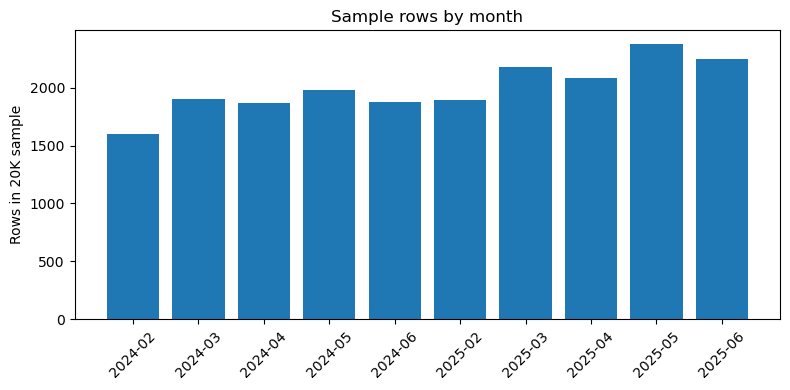

In [5]:
fig, ax = plt.subplots(figsize=(8, 4))
labels = sample_by_month["year"].astype(str) + "-" + sample_by_month["month"].astype(str).str.zfill(2)
ax.bar(labels, sample_by_month["sample_rows"])
ax.set_title("Sample rows by month")
ax.set_ylabel("Rows in 20K sample")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

## 2. Missingness Check

Before interpreting any field, we need to know whether missing values are random data-quality problems or systematic reporting differences. 

This section checks overall missingness, missingness of core and/or diagnostic fields by year, and missingness by payment type.

In [6]:
missing_summary = pd.DataFrame({
    "missing_count": sample.isna().sum(),
    "missing_pct": 100 * sample.isna().mean(),
    "dtype": sample.dtypes.astype(str),
}).sort_values("missing_pct", ascending=False)

missing_summary[missing_summary["missing_count"] > 0]

,missing_count,missing_pct,dtype
passenger_count,3635,18.1750,float64
RatecodeID,3635,18.1750,float64
airport_fee,3635,18.1750,float64
congestion_surcharge,3635,18.1750,float64


In [7]:
# Selected columns for missingness review.
# These are not all used in the same way later:
# - passenger_cost_pretip, cbd_congestion_fee, payment_type, etc. are core analysis fields;
# - congestion_surcharge and airport_fee are meaningful fee components, but may be structurally missing for Flex Fare rows;
# - passenger_count is not central to our burden analysis, but helps diagnose the same Flex Fare reporting pattern.
selected_missingness_cols = [
    "passenger_count",
    "RatecodeID",
    "extra",
    "mta_tax",
    "congestion_surcharge",
    "airport_fee",
    "improvement_surcharge",
    "fare_amount",
    "tip_amount",
    "total_amount",
    "payment_type",
    "cbd_congestion_fee",
    "passenger_cost_pretip",
    "relative_cbd_burden",
]

missing_by_year = (
    sample.groupby("year")[selected_missingness_cols]
    .apply(lambda g: 100 * g.isna().mean())
    .round(2)
)

missing_by_year

,passenger_count,RatecodeID,extra,mta_tax,congestion_surcharge,airport_fee,improvement_surcharge,fare_amount,tip_amount,total_amount,payment_type,cbd_congestion_fee,passenger_cost_pretip,relative_cbd_burden
year,,,,,,,,,,,,,,
2024,10.6800,10.6800,0.0000,0.0000,10.6800,10.6800,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
2025,24.5900,24.5900,0.0000,0.0000,24.5900,24.5900,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000


In [8]:
# Missingness by payment type checks whether the selected missing columns are tied to a payment/reporting regime.
missing_by_payment = (
    sample.groupby("yellow_payment_type_label", dropna=False)[selected_missingness_cols]
    .apply(lambda g: 100 * g.isna().mean())
    .round(2)
    .sort_index()
)

missing_by_payment

,passenger_count,RatecodeID,extra,mta_tax,congestion_surcharge,airport_fee,improvement_surcharge,fare_amount,tip_amount,total_amount,payment_type,cbd_congestion_fee,passenger_cost_pretip,relative_cbd_burden
yellow_payment_type_label,,,,,,,,,,,,,,
Cash,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
Credit card,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
Dispute,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
Flex Fare,100.0000,100.0000,0.0000,0.0000,100.0000,100.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
No charge,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000


In [9]:
# Check whether missing component fields are concentrated in Flex Fare rows.
component_cols_to_check = ["passenger_count", "RatecodeID", "congestion_surcharge", "airport_fee"]

flex_missing_check = (
    sample.assign(any_component_missing=sample[component_cols_to_check].isna().any(axis=1))
    .groupby(["flex_fare_flag", "any_component_missing"])
    .agg(
        sample_rows=("sample_row_id", "count"),
        weighted_count=("sample_weight", "sum"),
    )
    .reset_index()
)

flex_missing_check["weighted_share_pct"] = (
    100 * flex_missing_check["weighted_count"] / sample["sample_weight"].sum()
)

flex_missing_check

,flex_fare_flag,any_component_missing,sample_rows,weighted_count,weighted_share_pct
0,False,False,16365,"30,410,628.3115",81.8249
1,True,True,3635,"6,754,848.6885",18.1751


### Missingness pattern display

The next display the conclusion we can draw from previous raw-data inspection:

1. all columns with missing values are missing together;
2. rows with missing values are exactly Flex Fare rows;
3. all Flex Fare rows have those same missing fields.

In [10]:
missing_cols = sample.columns[sample.isna().any()].tolist()
missing_indicator = sample[missing_cols].isna().astype(int)
any_missing = missing_indicator.any(axis=1)

if missing_cols:
    all_missing_cols_move_together = missing_indicator.eq(missing_indicator.iloc[:, 0], axis=0).all().all()
else:
    all_missing_cols_move_together = True

missing_fact_check = pd.Series({
    "columns_with_any_missing": ", ".join(missing_cols),
    "n_columns_with_missing": len(missing_cols),
    "rows_with_any_missing": int(any_missing.sum()),
    "flex_fare_rows": int(sample["flex_fare_flag"].sum()),
    "all_missing_columns_move_together": bool(all_missing_cols_move_together),
    "all_rows_with_missing_are_flex_fare": bool(sample.loc[any_missing, "flex_fare_flag"].all()),
    "all_flex_fare_rows_have_missing_values": bool(any_missing.loc[sample["flex_fare_flag"]].all()),
})

missing_fact_check.to_frame("value")

,value
columns_with_any_missing,"congestion_surcharge, airport_fee, passenger_c..."
n_columns_with_missing,4
rows_with_any_missing,3635
flex_fare_rows,3635
all_missing_columns_move_together,True
all_rows_with_missing_are_flex_fare,True
all_flex_fare_rows_have_missing_values,True


In [11]:
missing_patterns = (
    sample[missing_cols]
    .isna()
    .astype(int)
    .value_counts()
    .rename("sample_rows")
    .reset_index()
)

missing_patterns

,congestion_surcharge,airport_fee,passenger_count,RatecodeID,sample_rows
0,0,0,0,0,16365
1,1,1,1,1,3635


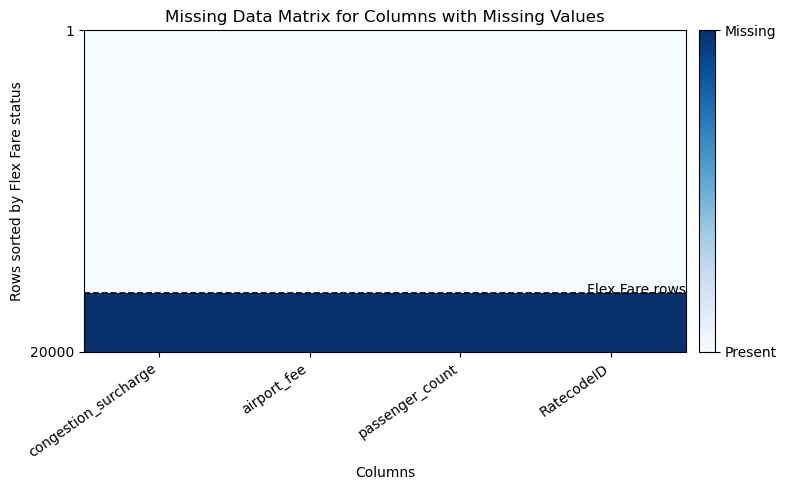

In [12]:
# Missing data matrix: dark cells are missing values.
# Rows are sorted so the Flex Fare block is visually separated.
plot_df = sample.sort_values(["flex_fare_flag", "year", "month", "sample_row_id"]).reset_index(drop=True)
missing_matrix = plot_df[missing_cols].isna().astype(int)
flex_start = int((~plot_df["flex_fare_flag"]).sum())

fig, ax = plt.subplots(figsize=(8, 5))
im = ax.imshow(missing_matrix, aspect="auto", interpolation="nearest", cmap="Blues", vmin=0, vmax=1)
ax.axhline(flex_start - 0.5, color="black", linewidth=1.2, linestyle="--")
ax.text(len(missing_cols) - 0.5, flex_start + 250, "Flex Fare rows", ha="right", va="bottom")
ax.set_title("Missing Data Matrix for Columns with Missing Values")
ax.set_xlabel("Columns")
ax.set_ylabel("Rows sorted by Flex Fare status")
ax.set_xticks(range(len(missing_cols)))
ax.set_xticklabels(missing_cols, rotation=35, ha="right")
ax.set_yticks([0, len(plot_df) - 1])
ax.set_yticklabels([1, len(plot_df)])
cbar = fig.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
cbar.set_ticks([0, 1])
cbar.set_ticklabels(["Present", "Missing"])
plt.tight_layout()
plt.show()

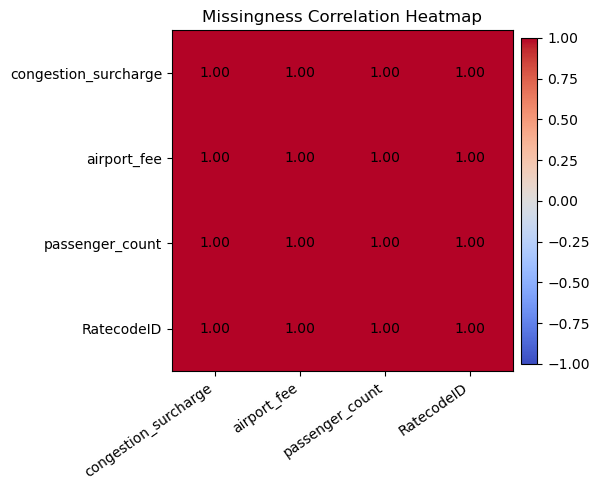

In [13]:
# Correlation of missingness indicators.
# A value of 1 means two columns are missing on exactly the same rows.
missing_corr = missing_indicator.corr()

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(missing_corr, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_title("Missingness Correlation Heatmap")
ax.set_xticks(range(len(missing_cols)))
ax.set_yticks(range(len(missing_cols)))
ax.set_xticklabels(missing_cols, rotation=35, ha="right")
ax.set_yticklabels(missing_cols)

for i in range(len(missing_cols)):
    for j in range(len(missing_cols)):
        ax.text(j, i, f"{missing_corr.iloc[i, j]:.2f}", ha="center", va="center", color="black")

fig.colorbar(im, ax=ax, fraction=0.04, pad=0.02)
plt.tight_layout()
plt.show()

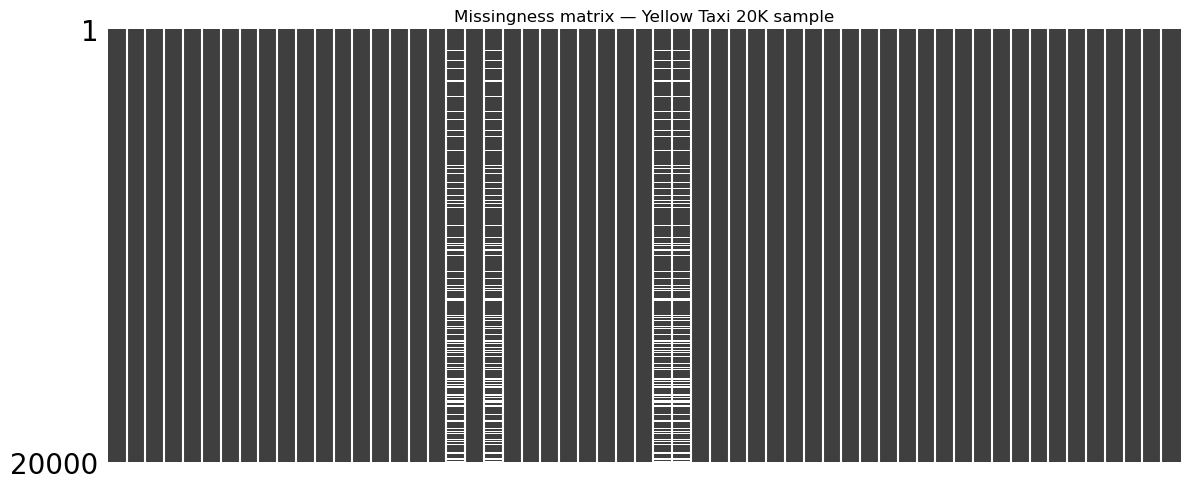

In [14]:
import missingno as msno
fig = msno.matrix(sample, figsize=(12, 5), sparkline=False)
plt.title("Missingness matrix — Yellow Taxi 20K sample")
plt.tight_layout()
plt.show()

**Explanation for the missingness pattern**

- Flex Fare trips are booked through licensed e-hail apps (e.g. Curb) and priced as a single upfront quote rather than a metered fare assembled from itemized components. Fields such as RatecodeID, congestion_surcharge, airport_fee, and passenger_count are missing on these rows by design: they are either taximeter-generated metadata that upfront-priced trips never produce, or itemized surcharges that get bundled into the quoted total and not reported separately. 

**Influence on our analysis**

- In this 20K representative sample, the main cost/burden fields are complete after first-step cleaning. The remaining missing values occur in `congestion_surcharge`, `airport_fee`, `passenger_count`, and `RatecodeID`. Some of these, especially `congestion_surcharge` and `airport_fee`, are still meaningful fee fields.
- Fields such as pickup/dropoff time, zone IDs, `cbd_congestion_fee`, `payment_type`, and `passenger_cost_pretip` remain complete after the team's conservative cleaning.
- The missingness is structural (missing not at random) and itself signals trip type — these rows should be flagged as a distinct payment regime rather than treated as ordinary data-entry gaps.



## 3. Cleaning Sanity Checks

This section checks whether any major invalid records still remain and identifies rows that are valid but should be flagged for later sensitivity checks.

Recall that team cleaning rules remove invalid timestamps, non-positive trip duration, missing zones, negative distance, negative CBD fee, and non-positive pre-tip passenger cost. Outliers such as zero-distance or very long trips are retained but flagged.

In [15]:
qc_cols = [
    "zero_distance_flag",
    "very_long_duration_flag",
    "very_long_distance_flag",
    "negative_cost_flag",
    "component_total_match_flag",
]

qc_summary = []
for col in qc_cols:
    if col in sample.columns:
        qc_summary.append({
            "flag": col,
            "unweighted_count": int(sample[col].fillna(False).sum()),
            "weighted_share_pct": 100 * weighted_share(sample[col].fillna(False), sample["sample_weight"]),
        })

pd.DataFrame(qc_summary).sort_values("weighted_share_pct", ascending=False)

,flag,unweighted_count,weighted_share_pct
4,component_total_match_flag,13299,66.4950
0,zero_distance_flag,447,2.2351
2,very_long_distance_flag,3,0.0150
1,very_long_duration_flag,0,0.0000
3,negative_cost_flag,0,0.0000


In [16]:
# Zero-distance trips: classify into cases using pickup/dropoff zones and trip plausibility.
# PU != DO with positive duration/cost can be a real trip with distance recording error; keep flagged.
# PU == DO with very short duration or very low cost is more consistent with cancellation/void-like records.

zd = sample[sample["zero_distance_flag"]].copy()
zd["same_zone"] = zd["PULocationID"] == zd["DOLocationID"]
zd["short_duration"] = zd["trip_duration_seconds"] < 60
zd["low_cost"] = zd["passenger_cost_pretip"] < 1

zd_summary = (
    zd.groupby("same_zone")
    .apply(lambda g: pd.Series({
        "sample_rows": len(g),
        "weighted_share_of_all_trips_pct": 100 * g["sample_weight"].sum() / sample["sample_weight"].sum(),
        "median_duration_sec": weighted_quantile(g["trip_duration_seconds"], g["sample_weight"], [0.5])[0],
        "median_passenger_cost": weighted_quantile(g["passenger_cost_pretip"], g["sample_weight"], [0.5])[0],
        "median_cbd_fee": weighted_quantile(g["cbd_congestion_fee"], g["sample_weight"], [0.5])[0],
        "low_cost_pct": 100 * weighted_share(g["low_cost"], g["sample_weight"]),
        "short_duration_pct": 100 * weighted_share(g["short_duration"], g["sample_weight"]),
        "flex_fare_pct": 100 * weighted_share(g["flex_fare_flag"], g["sample_weight"]),
        "same_pickup_dropoff_zone_pct": 100 * weighted_share(g["PULocationID"] == g["DOLocationID"], g["sample_weight"]),
    }))
    .rename(index={False: "PU != DO", True: "PU == DO"})
    .reset_index()
    .rename(columns={"same_zone": "zone_match"})
)

print("Zero-distance rows by pickup/dropoff zone match:")
zd_summary

Zero-distance rows by pickup/dropoff zone match:


,zone_match,sample_rows,weighted_share_of_all_trips_pct,median_duration_sec,median_passenger_cost,median_cbd_fee,low_cost_pct,short_duration_pct,flex_fare_pct,same_pickup_dropoff_zone_pct
0,PU != DO,307.0000,1.5350,996.9954,20.2299,0.7500,0.0000,1.6286,82.4115,0.0000
1,PU == DO,140.0000,0.7000,12.0000,20.4005,0.0000,0.0000,81.4296,11.4288,100.0000


**Findings from this section**

- Zero-distance trips split by whether the trip actually **moved** (distance *and* duration), not by PU/DO alone:
  - **PU == DO** (140 rows, 0.70% weighted): median duration **12 s**, 81% under 60 s — non-movement (cancellation / void / meter error), even when a charge is present.
  - **PU != DO** (307 rows, 1.54%): median duration **997 s (~17 min)**, only 1.6% under 60 s — genuine trips whose distance was mis-recorded. Note **82% of these are Flex Fare** (whose distance is unreliable); the card/cash remainder are true recording errors.
- **Decision (burden / DS_z):** drop non-movement — `zero_distance AND (PU == DO OR duration < 60 s)`; keep genuine `zero_distance AND PU != DO AND duration >= 60 s` flagged, excluded only from distance/speed/fare-per-mile views. Magnitude is negligible (~0.6% of card/cash, 0.32% of the 2025-charged DS_z population). `duration == 0` cannot occur (non-positive duration is dropped upstream).
- Component-sum checks are useful for data-quality review, but `passenger_cost_pretip = total_amount - tip_amount` remains the cleaner working cost definition for Yellow Taxi.

## 4. Payment Type and Flex Fare

Yellow Taxi has several payment categories. We have found in the missingness pattern section that the Flex Fare is structurally different than other categories. Here we do a thorough analysis to signal records that need separate handling.



In [17]:
payment_summary = (
    sample.groupby(["payment_type", "yellow_payment_type_label"], dropna=False)
    .apply(lambda g: pd.Series({
        "sample_rows": len(g),
        "weighted_share_pct": 100 * g["sample_weight"].sum() / sample["sample_weight"].sum(),
        "median_passenger_cost_pretip": weighted_quantile(g["passenger_cost_pretip"], g["sample_weight"], [0.5])[0],
    }))
    .reset_index()
    .sort_values("weighted_share_pct", ascending=False)
)

payment_summary

,payment_type,yellow_payment_type_label,sample_rows,weighted_share_pct,median_passenger_cost_pretip
1,1,Credit card,"13,876.0000",69.3799,18.5000
0,0,Flex Fare,"3,635.0000",18.1751,20.6900
2,2,Cash,"2,183.0000",10.9150,17.5000
4,4,Dispute,225.0000,1.1250,17.8500
3,3,No charge,81.0000,0.4050,14.9996


In [18]:
year_weight_totals = sample.groupby("year")["sample_weight"].sum()

payment_by_year = (
    sample.groupby(["year", "yellow_payment_type_label"], dropna=False)
    .agg(
        weighted_count=("sample_weight", "sum"),
        sample_rows=("sample_row_id", "count"),
    )
    .reset_index()
)

payment_by_year["weighted_share_pct_within_year"] = (
    100
    * payment_by_year["weighted_count"]
    / payment_by_year["year"].map(year_weight_totals)
)

payment_pivot = payment_by_year.pivot(
    index="yellow_payment_type_label",
    columns="year",
    values="weighted_share_pct_within_year",
).fillna(0).sort_values(2025, ascending=False)

payment_pivot

year,2024,2025
yellow_payment_type_label,,
Credit card,74.9106,64.6469
Flex Fare,10.6796,24.5894
Cash,13.0761,9.0656
Dispute,1.0083,1.2249
No charge,0.3253,0.4732


In [19]:
# Cost distribution by year and payment regime (Flex Fare vs standard card/cash).
# If Flex Fare cost differs systematically from card/cash, shifts in Flex Fare share
# between 2024 and 2025 can move the overall average independently of any policy effect.
flex_vs_standard = (
    sample[sample["payment_type"].isin([0, 1, 2])]
    .groupby(["year", "yellow_payment_type_label"])
    .apply(lambda g: pd.Series({
        "sample_rows": len(g),
        "weighted_share_pct": 100 * g["sample_weight"].sum() / sample["sample_weight"].sum(),
        "median_cost": weighted_quantile(g["passenger_cost_pretip"], g["sample_weight"], [0.5])[0],
        "p25_cost": weighted_quantile(g["passenger_cost_pretip"], g["sample_weight"], [0.25])[0],
        "p75_cost": weighted_quantile(g["passenger_cost_pretip"], g["sample_weight"], [0.75])[0],
        "median_distance": weighted_quantile(g["trip_distance_miles"], g["sample_weight"], [0.5])[0],
        "median_duration_min": weighted_quantile(g["trip_duration_seconds"] / 60, g["sample_weight"], [0.5])[0],
    }))
    .reset_index()
    .sort_values(["year", "weighted_share_pct"], ascending=[True, False])
)

flex_vs_standard

,year,yellow_payment_type_label,sample_rows,weighted_share_pct,median_cost,p25_cost,p75_cost,median_distance,median_duration_min
1,2024,Credit card,"6,909.0000",34.5441,18.2000,14.0000,26.3000,1.7200,12.6167
0,2024,Cash,"1,206.0000",6.0299,17.2000,13.3000,24.9000,1.5350,11.6667
2,2024,Flex Fare,985.0000,4.9248,21.4197,15.8949,29.6474,2.2900,15.3332
4,2025,Credit card,"6,967.0000",34.8358,18.5500,14.4500,26.3500,1.6900,12.3833
5,2025,Flex Fare,"2,650.0000",13.2503,20.3351,13.1401,28.7800,2.3600,15.6495
3,2025,Cash,977.0000,4.8851,17.8500,13.3500,26.3483,1.5000,11.4666


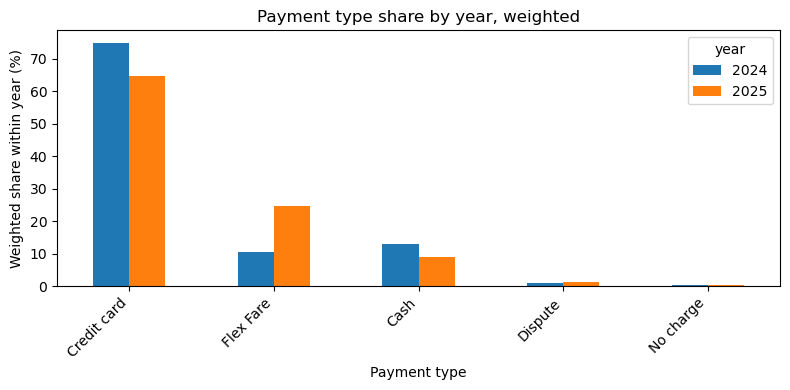

In [20]:
payment_pivot.plot(kind="bar", figsize=(8, 4))
plt.title("Payment type share by year, weighted")
plt.ylabel("Weighted share within year (%)")
plt.xlabel("Payment type")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

**Findings from this section**

- Credit card and cash are the cleanest payment categories for standard passenger-burden analysis.
- Flex Fare is large enough that it should not be ignored, but it should be analyzed separately or included only with a clear flag.
- No charge, dispute, unknown, and voided trips should be excluded from the main burden analysis or handled through sensitivity checks, because the passenger payment outcome is ambiguous.
- For trip volume and geographic analysis, No charge and Dispute rows represent real trips and may be included; they should only be excluded when the outcome of interest is passenger payment or financial burden.
- Flex Fare cost and distance distributions are modestly higher than card/cash trips, but the more important pattern is the compositional shift: Flex Fare's weighted share nearly tripled from 4.8% in 2024 to 13.3% in 2025. This means pre/post comparisons of overall median cost will partly reflect this regime shift rather than pure policy effects, and should be stratified by payment regime or explicitly control for Flex Fare share.

/var/folders/vt/9yl151q908915k56sck33jp40000gn/T/ipykernel_66824/3029078670.py:31: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(plot_data, labels=labels, showfliers=False)
/var/folders/vt/9yl151q908915k56sck33jp40000gn/T/ipykernel_66824/3029078670.py:31: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(plot_data, labels=labels, showfliers=False)
/var/folders/vt/9yl151q908915k56sck33jp40000gn/T/ipykernel_66824/3029078670.py:31: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(plot_data, labels=labels, showfliers=False)
/var/folders/vt/9yl151q908915k56sck33jp40000gn/T/ipykernel_66824/30290786

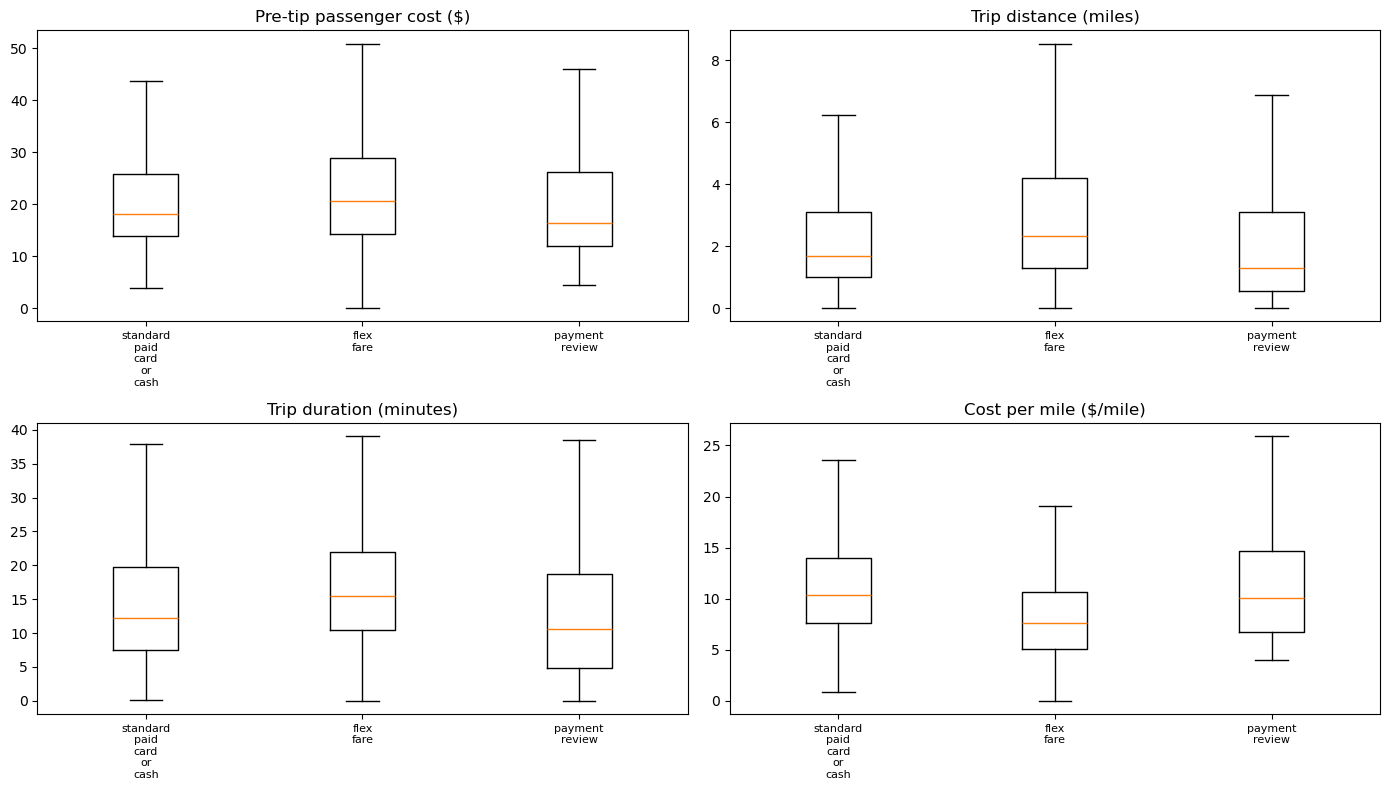

In [21]:
# (reproducibility fix) boxplot_df was originally created in a later cell that had been
# run out of order; define it here so this cell runs top-to-bottom. Same construction.
boxplot_df = sample.copy()
boxplot_df["trip_duration_minutes"] = boxplot_df["trip_duration_seconds"] / 60

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
regime_order = ["standard_paid_card_or_cash", "flex_fare", "payment_review"]

regime_boxplot_specs = [
    ("passenger_cost_pretip", "Pre-tip passenger cost ($)", 0.99),
    ("trip_distance_miles", "Trip distance (miles)", 0.99),
    ("trip_duration_minutes", "Trip duration (minutes)", 0.99),
    ("cost_per_mile", "Cost per mile ($/mile)", 0.98),
]

boxplot_df["cost_per_mile"] = np.where(
    boxplot_df["trip_distance_miles"] > 0,
    boxplot_df["passenger_cost_pretip"] / boxplot_df["trip_distance_miles"],
    np.nan,
)

for ax, (col, title, qmax) in zip(axes.ravel(), regime_boxplot_specs):
    plot_data = []
    labels = []
    upper = boxplot_df[col].quantile(qmax)
    for regime in regime_order:
        values = boxplot_df.loc[(boxplot_df["trip_regime"] == regime) & (boxplot_df[col] <= upper), col].dropna()
        if len(values) > 0:
            plot_data.append(values)
            labels.append(regime.replace("_", "\n"))
    ax.boxplot(plot_data, labels=labels, showfliers=False)
    ax.set_title(title)
    ax.tick_params(axis="x", labelsize=8)

plt.tight_layout()
plt.show()

## 5. Cost Component Reliability and Special Trip Regimes

This section addresses a key data-quality question: which Yellow Taxi records can be used safely for passenger-cost and CBD-burden analysis, and which records should be flagged or separated?

From raw-data inspection, we saw that some records have unusual fee/component patterns, especially Flex Fare rows. Here we check this systematically in the cleaned 20K representative sample. The main raw Yellow Taxi fee fields are: `fare_amount`, `extra`, `mta_tax`, `congestion_surcharge`, `tolls`, `airport_fee`, `improvement_surcharge`, `cbd_congestion_fee`, and `tip_amount`.


One natural thing to check is if the fee-related columns have abnormal value, i.e. any negative component or coexisting mixed sign components (e.g. 'mta_tax' negative and 'airport_fee' positive) . Flex Fare rows still require separate interpretation because some itemized components are structurally missing or bundled into the upfront quoted fare.

In [22]:
fee_cols = [
    "fare_amount",
    "extra",
    "mta_tax",
    "congestion_surcharge",
    "tolls",
    "airport_fee",
    "improvement_surcharge",
    "cbd_congestion_fee",
    "tip_amount",
]

regime_conditions = [
    sample["flex_fare_flag"],
    sample["yellow_payment_review_flag"],
    sample["yellow_card_or_cash_flag"],
]
regime_labels = ["flex_fare", "payment_review", "standard_paid_card_or_cash"]

sample["trip_regime"] = np.select(regime_conditions, regime_labels, default="other")

component_values = sample[fee_cols]
sample["missing_available_component_flag"] = component_values.isna().any(axis=1)
sample["any_negative_available_component_flag"] = component_values.lt(0).any(axis=1)
sample["any_positive_available_component_flag"] = component_values.gt(0).any(axis=1)
sample["mixed_sign_available_component_flag"] = (
    sample["any_negative_available_component_flag"]
    & sample["any_positive_available_component_flag"]
)

component_reliability_summary = (
    sample.groupby("trip_regime")
    .apply(lambda g: pd.Series({
        "sample_rows": len(g),
        "weighted_share_pct": 100 * g["sample_weight"].sum() / sample["sample_weight"].sum(),
        "missing_available_component_pct": 100 * weighted_share(g["missing_available_component_flag"], g["sample_weight"]),
        "any_negative_available_component_pct": 100 * weighted_share(g["any_negative_available_component_flag"], g["sample_weight"]),
        "mixed_sign_available_component_pct": 100 * weighted_share(g["mixed_sign_available_component_flag"], g["sample_weight"]),
        "zero_distance_pct": 100 * weighted_share(g["zero_distance_flag"], g["sample_weight"]),
        "charged_cbd_share_pct": 100 * weighted_share(g["charged_cbd_flag"], g["sample_weight"]),
    }))
    .reset_index()
    .sort_values("weighted_share_pct", ascending=False)
)

component_reliability_summary

,trip_regime,sample_rows,weighted_share_pct,missing_available_component_pct,any_negative_available_component_pct,mixed_sign_available_component_pct,zero_distance_pct,charged_cbd_share_pct
2,standard_paid_card_or_cash,"16,059.0000",80.2949,0.0000,0.0000,0.0000,0.9216,37.0642
0,flex_fare,"3,635.0000",18.1751,100.0000,13.1224,13.1224,7.4006,51.1427
1,payment_review,306.0000,1.5300,0.0000,0.0000,0.0000,9.8035,40.5235


In [23]:
component_sign_by_payment = (
    sample.groupby("yellow_payment_type_label", dropna=False)
    .apply(lambda g: pd.Series({
        "sample_rows": len(g),
        "weighted_share_pct": 100 * g["sample_weight"].sum() / sample["sample_weight"].sum(),
        "missing_available_component_pct": 100 * weighted_share(g["missing_available_component_flag"], g["sample_weight"]),
        "any_negative_available_component_pct": 100 * weighted_share(g["any_negative_available_component_flag"], g["sample_weight"]),
        "mixed_sign_available_component_pct": 100 * weighted_share(g["mixed_sign_available_component_flag"], g["sample_weight"]),
    }))
    .reset_index()
    .sort_values("weighted_share_pct", ascending=False)
)

component_sign_by_payment

,yellow_payment_type_label,sample_rows,weighted_share_pct,missing_available_component_pct,any_negative_available_component_pct,mixed_sign_available_component_pct
1,Credit card,"13,876.0000",69.3799,0.0000,0.0000,0.0000
3,Flex Fare,"3,635.0000",18.1751,100.0000,13.1224,13.1224
0,Cash,"2,183.0000",10.9150,0.0000,0.0000,0.0000
2,Dispute,225.0000,1.1250,0.0000,0.0000,0.0000
4,No charge,81.0000,0.4050,0.0000,0.0000,0.0000


In [24]:
negative_component_breakdown = []
for col in fee_cols:
    mask = sample[col] < 0
    negative_component_breakdown.append({
        "component": col,
        "negative_sample_rows": int(mask.sum()),
        "negative_weighted_share_pct": 100 * weighted_share(mask, sample["sample_weight"]),
        "negative_rows_flex_share_pct": 100 * sample.loc[mask, "flex_fare_flag"].mean() if mask.sum() else 0,
    })

pd.DataFrame(negative_component_breakdown).sort_values("negative_weighted_share_pct", ascending=False)

,component,negative_sample_rows,negative_weighted_share_pct,negative_rows_flex_share_pct
0,fare_amount,477,2.3850,100.0000
1,extra,0,0.0000,0.0000
2,mta_tax,0,0.0000,0.0000
3,congestion_surcharge,0,0.0000,0.0000
4,tolls,0,0.0000,0.0000
5,airport_fee,0,0.0000,0.0000
6,improvement_surcharge,0,0.0000,0.0000
7,cbd_congestion_fee,0,0.0000,0.0000
8,tip_amount,0,0.0000,0.0000


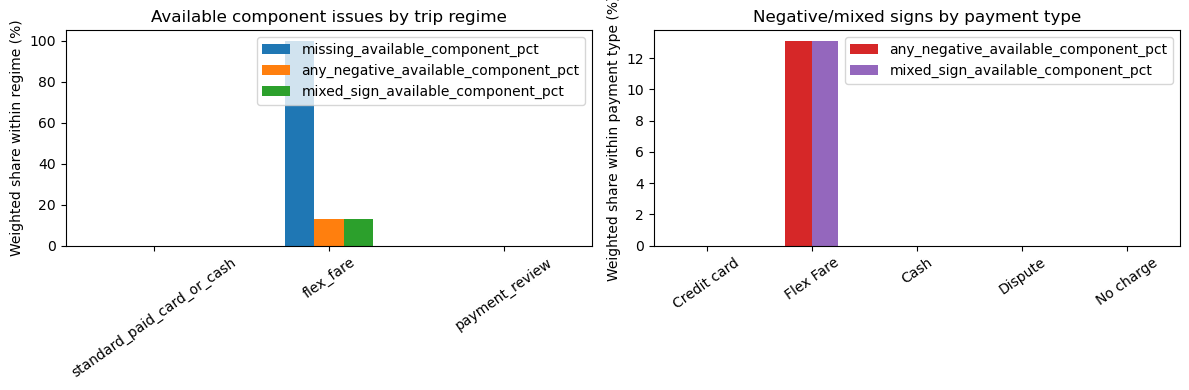

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

plot_summary = component_reliability_summary.set_index("trip_regime")
plot_summary[[
    "missing_available_component_pct",
    "any_negative_available_component_pct",
    "mixed_sign_available_component_pct",
]].plot(kind="bar", ax=axes[0])
axes[0].set_title("Available component issues by trip regime")
axes[0].set_ylabel("Weighted share within regime (%)")
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=35)

component_sign_by_payment.set_index("yellow_payment_type_label")[[
    "any_negative_available_component_pct",
    "mixed_sign_available_component_pct",
]].plot(kind="bar", ax=axes[1], color=["tab:red", "tab:purple"])
axes[1].set_title("Negative/mixed signs by payment type")
axes[1].set_ylabel("Weighted share within payment type (%)")
axes[1].set_xlabel("")
axes[1].tick_params(axis="x", rotation=35)

plt.tight_layout()
plt.show()

Negative and mixed-sign fee components are concentrated in Flex Fare rows. This is consistent with the fact that Flex Fare trips are upfront-priced rather than standard metered trips with fully itemized fare components. Therefore, component-level fields for Flex Fare should not be interpreted in the same way as standard metered taxi records.

However, this does not necessarily undermine the reliability of `total_amount`. For Flex Fare, the passenger accepts an upfront quoted fare, so `total_amount` is likely the more reliable passenger-facing cost measure than the individual component fields.

### Component-total consistency check

The includes the main raw Yellow Taxi fee fields needed for a component-total check: `fare_amount`, `extra`, `mta_tax`, `congestion_surcharge`, `tolls`, `airport_fee`, `improvement_surcharge`, `cbd_congestion_fee`, and `tip_amount`.

This lets us test a naive itemized reconciliation:

```text
total_amount ?= fare_amount + extra + mta_tax + congestion_surcharge + tolls + airport_fee + improvement_surcharge + cbd_congestion_fee + tip_amount
```

In [26]:
diff_summary = (
    sample.groupby("trip_regime")
    .apply(lambda g: pd.Series({
        "sample_rows": len(g),
        "component_total_match_pct": 100 * weighted_share(g["component_total_match_flag"], g["sample_weight"]),
        "median_component_total_diff": weighted_quantile(g["component_total_diff"], g["sample_weight"], [0.5])[0],
        "p25_component_total_diff": weighted_quantile(g["component_total_diff"], g["sample_weight"], [0.25])[0],
        "p75_component_total_diff": weighted_quantile(g["component_total_diff"], g["sample_weight"], [0.75])[0],
    }))
    .reset_index()
)

diff_summary

,trip_regime,sample_rows,component_total_match_pct,median_component_total_diff,p25_component_total_diff,p75_component_total_diff
0,flex_fare,"3,635.0000",15.7909,2.5000,2.5000,2.5000
1,payment_review,306.0000,78.4316,0.0000,0.0000,0.0000
2,standard_paid_card_or_cash,"16,059.0000",77.7445,0.0000,0.0000,0.0000


In [27]:
sample["component_total_diff"].value_counts().head(15).to_frame("sample_rows")

,sample_rows
component_total_diff,
0.0000,13299
2.5000,2644
-2.5000,2092
-3.2500,1279
-1.7500,98
-4.2500,81
-5.0000,53
3.5000,30
5.5000,25


**Findings from this section**

- In the cleaned 20K sample, standard paid card/cash trips have nonnegative available cost components. Negative available components are concentrated in Flex Fare rows, especially negative `fare_amount`.
- Flex Fare rows are therefore a separate reporting/payment regime. They can remain in broad trip-volume or CBD-fee exposure summaries, but component-level fee interpretation should not mix them with standard metered trips.
- Payment review rows (`No charge`, `Dispute`, etc.) are not necessarily negative in this cleaned sample, but their payment outcome is ambiguous. They should be excluded from the main passenger-burden analysis and used only in sensitivity checks.
- For the component-total matching analysis: the fixed differences of `$2.50` and `$3.25` align with the old NYS congestion surcharge and the old surcharge plus the new `$0.75` CBD fee. This suggests that `extra` or other accounting fields may sometimes already bundle these charges, so a naive sum of every displayed fee field can double-count.
- Decision: continue to trust `total_amount` as the passenger charge field and use `passenger_cost_pretip = total_amount - tip_amount`. This decision is especially important for Flex Fare rows, where the upfront quoted `total_amount` is more reliable than incomplete itemized components. For standard metered trips, component matching remains useful as QC, but mismatches should be interpreted by trip regime and fixed-difference pattern rather than used as an automatic deletion rule.


## 6. CBD Congestion Fee and Relative Burden

This section checks the project's core fee variable: `cbd_congestion_fee`.

For Yellow Taxi passenger trips, the expected post-policy CBD charge is usually $0.75 when the trip is subject to the new congestion pricing rule. Pre-policy 2024 rows should have CBD fee equal to zero.

In [28]:
cbd_value_counts = (
    sample.groupby(["year", "cbd_congestion_fee"])
    .agg(sample_rows=("sample_row_id", "count"), estimated_population=("sample_weight", "sum"))
    .reset_index()
    .sort_values(["year", "estimated_population"], ascending=[True, False])
)

cbd_value_counts.head(20)

,year,cbd_congestion_fee,sample_rows,estimated_population
0,2024,0.0000,9223,"17,138,396.0000"
2,2025,0.7500,7935,"14,745,741.5130"
1,2025,0.0000,2842,"5,281,339.4870"


In [29]:
# CBD charging is policy-specific, so summarize it by year-month.
# 2024 is kept here as a falsification/sanity check: it should be zero before the CBD policy.
cbd_summary_by_month = (
    sample.groupby(["year", "month"])
    .apply(lambda g: pd.Series({
        "sample_rows": len(g),
        "estimated_cleaned_population": g["sample_weight"].sum(),
        "weighted_charged_share_pct": 100 * weighted_share(g["charged_cbd_flag"], g["sample_weight"]),
        "weighted_mean_cbd_fee": weighted_mean(g["cbd_congestion_fee"], g["sample_weight"]),
        "weighted_median_passenger_cost_pretip": weighted_quantile(g["passenger_cost_pretip"], g["sample_weight"], [0.5])[0],
    }))
    .reset_index()
)

cbd_summary_by_month

,year,month,sample_rows,estimated_cleaned_population,weighted_charged_share_pct,weighted_mean_cbd_fee,weighted_median_passenger_cost_pretip
0,2024,2,"1,598.0000","2,970,277.0000",0.0000,0.0000,17.5000
1,2024,3,"1,903.0000","3,536,782.0000",0.0000,0.0000,18.2000
2,2024,4,"1,867.0000","3,469,080.0000",0.0000,0.0000,18.5000
3,2024,5,"1,977.0000","3,673,319.0000",0.0000,0.0000,18.9000
4,2024,6,"1,878.0000","3,488,938.0000",0.0000,0.0000,18.6000
5,2025,2,"1,892.0000","3,516,753.0000",74.4715,0.5585,18.5500
6,2025,3,"2,181.0000","4,053,697.0000",73.0399,0.5478,18.8000
7,2025,4,"2,079.0000","3,862,613.0000",74.1703,0.5563,18.3100
8,2025,5,"2,376.0000","4,414,520.0000",73.6532,0.5524,19.3500
9,2025,6,"2,249.0000","4,179,498.0000",72.9658,0.5472,19.6500


In [30]:
# Relative burden is only substantively meaningful once the CBD fee exists.
# Therefore, summarize burden by month for 2025 charged trips only.
charged_2025 = sample[(sample["year"] == 2025) & (sample["charged_cbd_flag"])].copy()

burden_by_month_2025 = (
    charged_2025.groupby("month")
    .apply(lambda g: pd.Series({
        "sample_rows": len(g),
        "estimated_charged_population": g["sample_weight"].sum(),
        "weighted_mean_burden_pct": 100 * weighted_mean(g["relative_cbd_burden"], g["sample_weight"]),
        "weighted_median_burden_pct": 100 * weighted_quantile(g["relative_cbd_burden"], g["sample_weight"], [0.5])[0],
        "weighted_p75_burden_pct": 100 * weighted_quantile(g["relative_cbd_burden"], g["sample_weight"], [0.75])[0],
    }))
    .reset_index()
)

burden_by_month_2025

,month,sample_rows,estimated_charged_population,weighted_mean_burden_pct,weighted_median_burden_pct,weighted_p75_burden_pct
0,2,"1,409.0000","2,618,977.2606",4.6743,3.9578,5.0847
1,3,"1,593.0000","2,960,815.8281",4.4029,3.8168,4.9834
2,4,"1,542.0000","2,864,910.6522",4.6551,3.9578,4.9505
3,5,"1,750.0000","3,251,435.1852",4.8244,3.7406,4.9834
4,6,"1,641.0000","3,049,602.5869",4.5666,3.6855,4.8544


In [31]:
# Overall burden distribution is reported only within 2025 charged trips.
# This is a distributional summary, not a pre/post comparison.
burden_summary = weighted_summary(charged_2025, "relative_cbd_burden")
burden_summary[["weighted_mean", "weighted_p25", "weighted_median", "weighted_p75", "unweighted_n"]].assign(
    weighted_mean=lambda d: 100 * d["weighted_mean"],
    weighted_p25=lambda d: 100 * d["weighted_p25"],
    weighted_median=lambda d: 100 * d["weighted_median"],
    weighted_p75=lambda d: 100 * d["weighted_p75"],
).rename(columns={
    "weighted_mean": "weighted_mean_pct",
    "weighted_p25": "weighted_p25_pct",
    "weighted_median": "weighted_median_pct",
    "weighted_p75": "weighted_p75_pct",
})

,weighted_mean_pct,weighted_p25_pct,weighted_median_pct,weighted_p75_pct,unweighted_n
0,4.6269,2.7936,3.8168,4.9834,7935


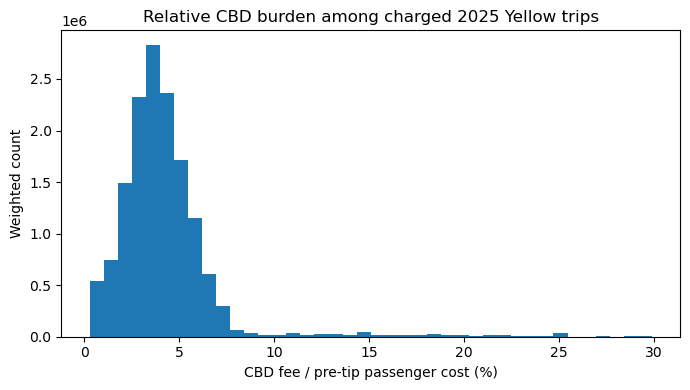

In [32]:
plot_df = charged_2025.loc[charged_2025["relative_cbd_burden"].between(0, 0.30)].copy()

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(plot_df["relative_cbd_burden"] * 100, bins=40, weights=plot_df["sample_weight"])
ax.set_title("Relative CBD burden among charged 2025 Yellow trips")
ax.set_xlabel("CBD fee / pre-tip passenger cost (%)")
ax.set_ylabel("Weighted count")
plt.tight_layout()
plt.show()

In [33]:
from scipy.stats import mstats

# Extreme-burden diagnostics should also use 2025 charged trips only.
burden_series = charged_2025["relative_cbd_burden"].dropna()
burden_win = mstats.winsorize(burden_series, limits=[0, 0.01])  # cap top 1%
p99 = burden_series.quantile(0.99)
print(f"99th percentile of relative_cbd_burden among 2025 charged trips: {p99:.4f}")
print(f"After winsorizing top 1%: max = {burden_win.max():.4f}")
print(f"Original max: {burden_series.max():.4f}")
print(f"N rows affected (> p99): {(burden_series > p99).sum()}")

99th percentile of relative_cbd_burden among 2025 charged trips: 0.2500
After winsorizing top 1%: max = 0.2500
Original max: 0.9494
N rows affected (> p99): 76


**Findings from this section**

- `charged_cbd_share` should be interpreted by month in 2025, because the policy exposure is event-time-specific.
- Extreme burden values can occur when pre-tip passenger cost is very small. These should be flagged or winsorized in later robustness checks rather than silently driving averages. 
- The burden distribution has a long right tail (p99 = 0.25 but max = 0.95), so the mean is sensitive to the 76 extreme-burden rows. Median or percentile-based summaries are preferred; if a mean is reported, winsorization should be applied and disclosed. 
- The extreme-valued high-burden trips represent low-cost short-haul passengers who bear the largest relative impact of the fixed $0.75 fee — precisely the population of policy interest. Dropping them would systematically understate the burden on the most affected riders. The correct approach is to retain them in the main analysis, report medians, and include a winsorized mean as a robustness check.

## 7. Passenger Cost, Trip Distance, and Trip Duration

This section checks the main trip-level variables that we may use as outcomes, controls, or denominators: passenger cost, distance, and duration.

For Yellow Taxi, the preferred passenger-cost measure is `passenger_cost_pretip = total_amount - tip_amount`.

Unlike CBD burden, these variables exist in both 2024 and 2025. However, they should still be summarized by month because a single overall 2024+2025 average mixes pre-policy and post-policy periods and hides event-time patterns.

In [34]:
core_vars = ["passenger_cost_pretip", "trip_distance_miles", "trip_duration_seconds"]

summary_parts = []
for var in core_vars:
    temp = weighted_summary(sample, var, group_cols=["year", "month"])
    temp.insert(0, "variable", var)
    summary_parts.append(temp)

core_summary_by_month = pd.concat(summary_parts, ignore_index=True)
core_summary_by_month

,variable,group,weighted_mean,weighted_p25,weighted_median,weighted_p75,unweighted_n
0,passenger_cost_pretip,"(2024, 2)",23.6153,13.6000,17.5000,24.8000,1598
1,passenger_cost_pretip,"(2024, 3)",24.3623,14.0000,18.2000,26.6000,1903
2,passenger_cost_pretip,"(2024, 4)",25.1236,14.0000,18.5000,27.2575,1867
3,passenger_cost_pretip,"(2024, 5)",25.6943,14.3000,18.9000,27.7000,1977
4,passenger_cost_pretip,"(2024, 6)",25.6066,14.3000,18.6000,27.3000,1878
5,passenger_cost_pretip,"(2025, 2)",23.1118,14.0500,18.5500,25.7300,1892
6,passenger_cost_pretip,"(2025, 3)",24.3525,14.0500,18.8000,26.6500,2181
7,passenger_cost_pretip,"(2025, 4)",23.6658,14.3825,18.3100,25.9500,2079
8,passenger_cost_pretip,"(2025, 5)",24.6501,14.0500,19.3500,28.3500,2376
9,passenger_cost_pretip,"(2025, 6)",25.3786,14.3500,19.6500,28.4500,2249


In [35]:
# Check whether very_long_distance rows concentrate in months with anomalous weighted mean.
long_dist = sample[sample["very_long_distance_flag"]][
    ["year", "month", "trip_distance_miles", "passenger_cost_pretip", "flex_fare_flag", "payment_type"]
].sort_values(["year", "month"])

print(f"Total very_long_distance rows (>100 miles): {len(long_dist)}")
print()
print(long_dist.to_string(index=False))

Total very_long_distance rows (>100 miles): 3

 year  month  trip_distance_miles  passenger_cost_pretip  flex_fare_flag  payment_type
 2024      2          67,156.3500                20.7500            True             0
 2025      3          90,783.7200                21.3600            True             0
 2025      4          83,627.3600                19.9300            True             0


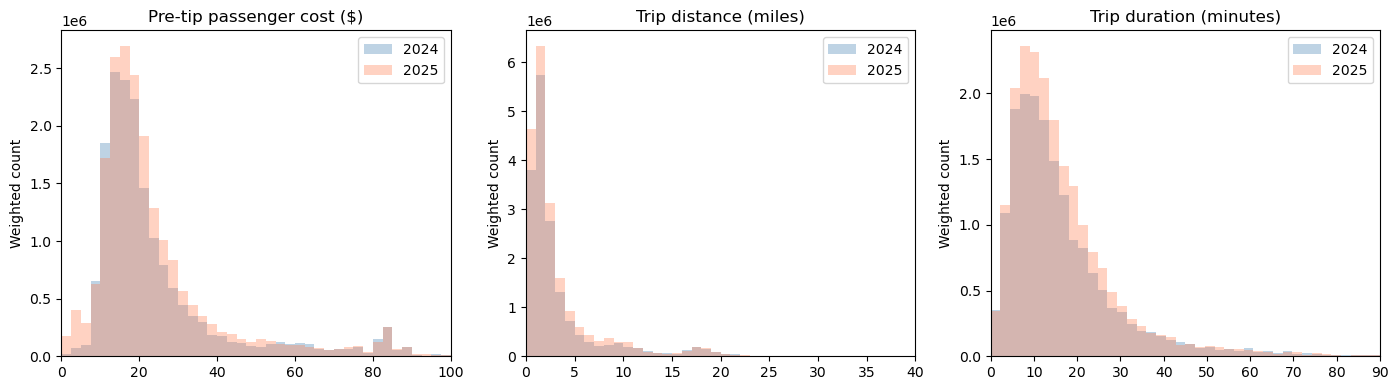

In [36]:
from scipy.stats import gaussian_kde

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
plot_specs = [
    ("passenger_cost_pretip", "Pre-tip passenger cost ($)", (0, 100)),
    ("trip_distance_miles", "Trip distance (miles)", (0, 40)),
    ("trip_duration_seconds", "Trip duration (minutes)", (0, 90 * 60)),
]

for ax, (col, label, xlim) in zip(axes, plot_specs):
    for year, color in zip([2024, 2025], ["steelblue", "coral"]):
        g = sample[sample["year"] == year]
        values = g[col] / 60 if col == "trip_duration_seconds" else g[col]
        this_xlim = (xlim[0] / 60, xlim[1] / 60) if col == "trip_duration_seconds" else xlim
        ax.hist(
            values,
            bins=40,
            range=this_xlim,
            weights=g["sample_weight"],
            alpha=0.35,
            label=str(year),
            color=color,
        )
    ax.set_title(label)
    ax.set_xlim(this_xlim)
    ax.set_ylabel("Weighted count")
    ax.legend()

plt.tight_layout()
plt.show()

**Findings from this section**

**Cost distribution**
- The passenger_cost_pretip distribution is right-skewed in both 2024 and 2025. The two years show broadly similar distribution shapes, with 2025 slightly shifted higher.
- Among 2025 card/cash trips, charged and not-charged trips have similar cost distributions, suggesting cost alone does not strongly predict whether a trip is charged.

**Outlier findings from earlier chapters (consolidated)**
- *Section 6 (CBD Fee)*: relative_cbd_burden is right-skewed with extreme values when the trip cost denominator is very small. The p99 cutoff is 0.25 (25%). Winsorization or median-based summaries should be used; extreme rows should not be dropped as they represent real short/cheap trips.
- *Section 7 (Cost/Distance/Duration)*: Three Flex Fare trips have trip_distance_miles of 67,000-90,000 miles — clearly garbage values from the taximeter bypass. Flex Fare distance is unreliable as a feature and should not be used in modeling.
- *Section 5 (Cost Components)*: Zero-distance trips fall into two categories — PU!=DO (real trips with recording errors, keep flagged) and PU==DO (likely cancelled/voided, drop). Component-total mismatches are concentrated in Flex Fare rows due to structural missingness.
- *Section 10 (Relationships)*: Airport trips with airport_fee>0 but no JFK/LGA zone ID (3% of airport trips) are concentrated in zone 70 (East Elmhurst). Exclude from airport-specific analysis but retain as valid trips in the general sample.

## 8. Time Patterns

This section checks whether CBD charging and trip volume patterns vary by pickup hour and day of week. This is not a causal comparison yet; it is a descriptive check to guide later feature engineering.

In [37]:
hourly = (
    sample.groupby(["year", "pickup_hour"])
    .apply(lambda g: pd.Series({
        "estimated_population": g["sample_weight"].sum(),
        "median_cost": weighted_quantile(g["passenger_cost_pretip"], g["sample_weight"], [0.5])[0],
    }))
    .reset_index()
)

hourly_2025_policy = (
    sample[sample["year"] == 2025]
    .groupby("pickup_hour")
    .apply(lambda g: pd.Series({
        "charged_cbd_share": weighted_share(g["charged_cbd_flag"], g["sample_weight"]),
    }))
    .reset_index()
)

# By regime: only card/cash and flex fare, 2025 only for financial metrics
regime_map = {True: "Flex Fare", False: "Card/Cash"}
hourly_regime_cost = (
    sample[sample["payment_type"].isin([0, 1, 2])]
    .assign(regime=lambda d: d["flex_fare_flag"].map(regime_map))
    .groupby(["year", "pickup_hour", "regime"])
    .apply(lambda g: pd.Series({
        "median_cost": weighted_quantile(g["passenger_cost_pretip"], g["sample_weight"], [0.5])[0],
    }))
    .reset_index()
)

hourly_2025_regime_cbd = (
    sample[(sample["year"] == 2025) & (sample["payment_type"].isin([0, 1, 2]))]
    .assign(regime=lambda d: d["flex_fare_flag"].map(regime_map))
    .groupby(["pickup_hour", "regime"])
    .apply(lambda g: pd.Series({
        "charged_cbd_share": weighted_share(g["charged_cbd_flag"], g["sample_weight"]),
    }))
    .reset_index()
)

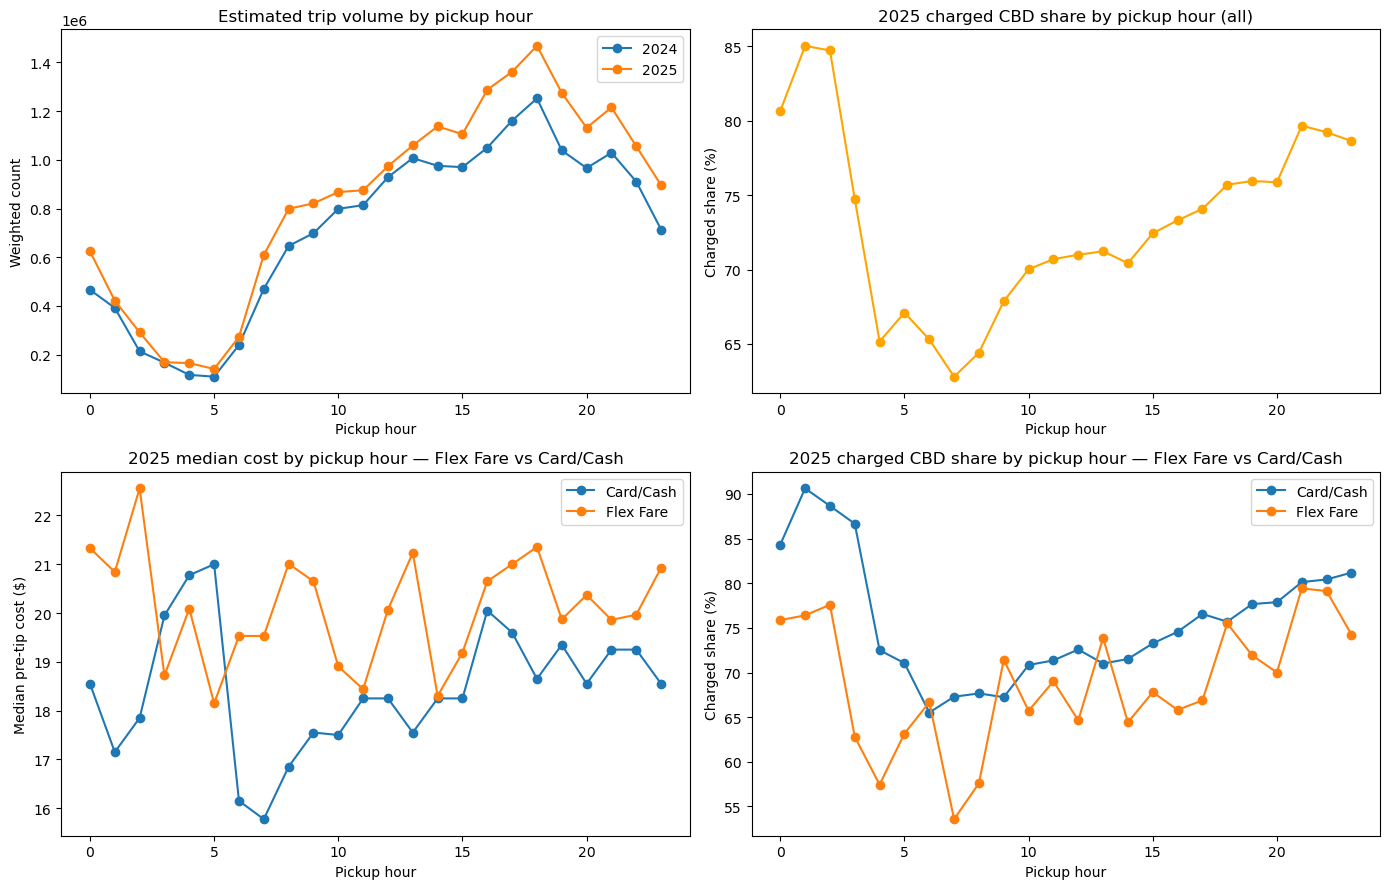

In [38]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# Top-left: trip volume by hour (no regime split)
for year in [2024, 2025]:
    g = hourly[hourly["year"] == year]
    axes[0, 0].plot(g["pickup_hour"], g["estimated_population"], marker="o", label=str(year))
axes[0, 0].set_title("Estimated trip volume by pickup hour")
axes[0, 0].set_xlabel("Pickup hour")
axes[0, 0].set_ylabel("Weighted count")
axes[0, 0].legend()

# Top-right: 2025 charged CBD share overall
axes[0, 1].plot(hourly_2025_policy["pickup_hour"],
                100 * hourly_2025_policy["charged_cbd_share"], marker="o", color="orange")
axes[0, 1].set_title("2025 charged CBD share by pickup hour (all)")
axes[0, 1].set_xlabel("Pickup hour")
axes[0, 1].set_ylabel("Charged share (%)")

# Bottom-left: median cost by hour, 2025, by regime
for regime, grp in hourly_regime_cost[hourly_regime_cost["year"] == 2025].groupby("regime"):
    axes[1, 0].plot(grp["pickup_hour"], grp["median_cost"], marker="o", label=regime)
axes[1, 0].set_title("2025 median cost by pickup hour — Flex Fare vs Card/Cash")
axes[1, 0].set_xlabel("Pickup hour")
axes[1, 0].set_ylabel("Median pre-tip cost ($)")
axes[1, 0].legend()

# Bottom-right: 2025 charged CBD share by regime
for regime, grp in hourly_2025_regime_cbd.groupby("regime"):
    axes[1, 1].plot(grp["pickup_hour"], 100 * grp["charged_cbd_share"], marker="o", label=regime)
axes[1, 1].set_title("2025 charged CBD share by pickup hour — Flex Fare vs Card/Cash")
axes[1, 1].set_xlabel("Pickup hour")
axes[1, 1].set_ylabel("Charged share (%)")
axes[1, 1].legend()

plt.tight_layout()
plt.show()

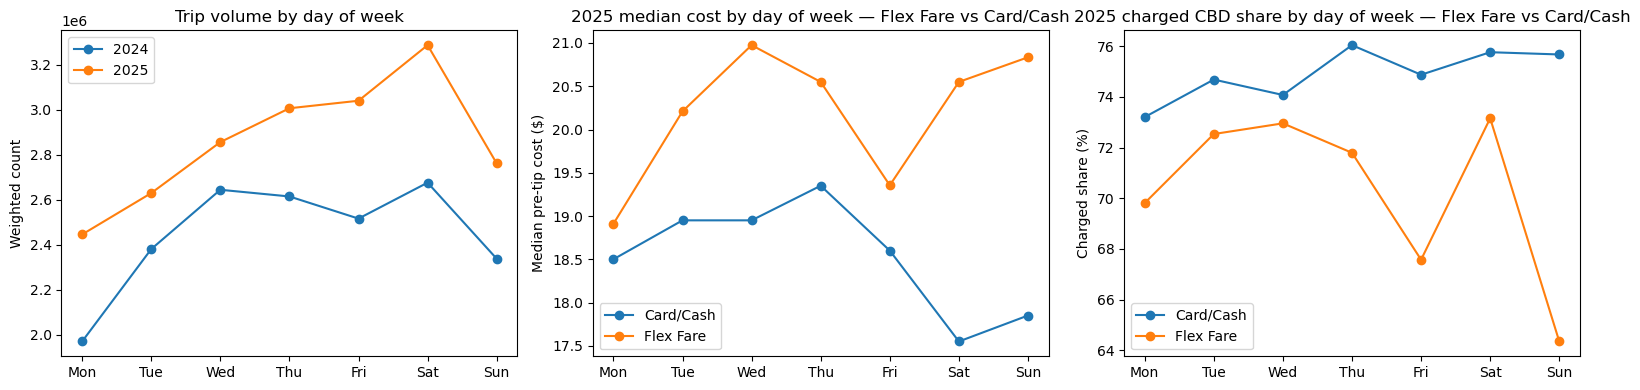

In [39]:
dow_labels = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

dow_summary = (
    sample.groupby(["year", "day_of_week"])
    .apply(lambda g: pd.Series({
        "estimated_population": g["sample_weight"].sum(),
        "median_cost": weighted_quantile(g["passenger_cost_pretip"], g["sample_weight"], [0.5])[0],
    }))
    .reset_index()
)
dow_summary["day"] = dow_summary["day_of_week"].map(dict(enumerate(dow_labels)))

dow_regime_cost = (
    sample[sample["payment_type"].isin([0, 1, 2])]
    .assign(regime=lambda d: d["flex_fare_flag"].map({True: "Flex Fare", False: "Card/Cash"}))
    .groupby(["year", "day_of_week", "regime"])
    .apply(lambda g: pd.Series({
        "median_cost": weighted_quantile(g["passenger_cost_pretip"], g["sample_weight"], [0.5])[0],
    }))
    .reset_index()
)
dow_regime_cost["day"] = dow_regime_cost["day_of_week"].map(dict(enumerate(dow_labels)))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Volume by day of week (no regime split)
for year in [2024, 2025]:
    g = dow_summary[dow_summary["year"] == year]
    axes[0].plot(g["day_of_week"], g["estimated_population"], marker="o", label=str(year))
axes[0].set_title("Trip volume by day of week")
axes[0].set_xticks(range(7))
axes[0].set_xticklabels(dow_labels)
axes[0].set_ylabel("Weighted count")
axes[0].legend()

# Median cost by day of week, 2025, by regime
for regime, grp in dow_regime_cost[dow_regime_cost["year"] == 2025].groupby("regime"):
    axes[1].plot(grp["day_of_week"], grp["median_cost"], marker="o", label=regime)
axes[1].set_title("2025 median cost by day of week — Flex Fare vs Card/Cash")
axes[1].set_xticks(range(7))
axes[1].set_xticklabels(dow_labels)
axes[1].set_ylabel("Median pre-tip cost ($)")
axes[1].legend()

# 2025 charged CBD share by day of week, by regime
dow_2025_regime_cbd = (
    sample[(sample["year"] == 2025) & (sample["payment_type"].isin([0, 1, 2]))]
    .assign(regime=lambda d: d["flex_fare_flag"].map({True: "Flex Fare", False: "Card/Cash"}))
    .groupby(["day_of_week", "regime"])
    .apply(lambda g: pd.Series({
        "charged_cbd_share": weighted_share(g["charged_cbd_flag"], g["sample_weight"]),
    }))
    .reset_index()
)
for regime, grp in dow_2025_regime_cbd.groupby("regime"):
    axes[2].plot(grp["day_of_week"], 100 * grp["charged_cbd_share"], marker="o", label=regime)
axes[2].set_title("2025 charged CBD share by day of week — Flex Fare vs Card/Cash")
axes[2].set_xticks(range(7))
axes[2].set_xticklabels(dow_labels)
axes[2].set_ylabel("Charged share (%)")
axes[2].legend()

plt.tight_layout()
plt.show()

**Findings from this section**

- Pickup hour and day of week are natural features for later comparisons because taxi demand and fee exposure are time-dependent.
- For first-pass EDA, time variables help us check whether post-policy changes could be partly driven by different temporal composition. Later analysis should compare similar months and consider hour/day controls or stratified summaries.
- Flex Fare and Card/Cash trips show systematically different median costs across hours and days of week, with Flex Fare consistently higher by $1–2 and more volatile. Financial metrics should not be reported for the two regimes combined.
- Flex Fare charged CBD share is more volatile across both pickup hour and day of week than Card/Cash. The pattern is particularly unstable on weekends, where Flex Fare charged share drops to 64–67% versus a stable ~75% for Card/Cash. This instability likely reflects unreliable zone recording for Flex Fare trips rather than a genuine behavioral pattern, and should be validated on full data before any interpretation is drawn.

## 9. Zone-Level First Look

This section gives a descriptive look at pickup and dropoff zones. TLC zone IDs are not exact addresses, but they are still useful for identifying whether CBD-charged trips concentrate around expected Manhattan zones.

This is only a sample look. Final zone-level rankings should use full-data aggregates.

In [40]:
zone_lookup = pd.read_csv(REPO_ROOT / "data/taxi_zone_lookup.csv")[["LocationID", "Borough", "Zone"]]

top_pu_2025_charged = (
    sample[(sample["year"] == 2025) & (sample["charged_cbd_flag"])]
    .groupby("PULocationID")
    .agg(
        estimated_charged_trips=("sample_weight", "sum"),
        sample_rows=("sample_row_id", "count"),
        median_relative_burden=("relative_cbd_burden", "median"),
    )
    .sort_values("estimated_charged_trips", ascending=False)
    .head(15)
    .reset_index()
    .merge(zone_lookup, left_on="PULocationID", right_on="LocationID", how="left")
    .drop(columns=["LocationID"])
    [["Borough", "Zone", "PULocationID", "estimated_charged_trips", "sample_rows", "median_relative_burden"]]
)

top_pu_2025_charged

,Borough,Zone,PULocationID,estimated_charged_trips,sample_rows,median_relative_burden
0,Manhattan,Midtown Center,161,"893,852.9986",481,0.0402
1,Manhattan,Times Sq/Theatre District,230,"639,262.5296",344,0.0396
2,Manhattan,Penn Station/Madison Sq West,186,"613,248.7474",330,0.0389
3,Manhattan,Midtown East,162,"603,956.2425",325,0.0402
4,Manhattan,Midtown North,163,"581,647.3609",313,0.0402
5,Manhattan,Murray Hill,170,"561,206.8166",302,0.0397
6,Manhattan,East Chelsea,68,"535,199.9964",288,0.0388
7,Manhattan,Union Sq,234,"525,905.5111",283,0.0437
8,Manhattan,East Village,79,"498,028.0957",268,0.0407
9,Manhattan,Upper East Side South,237,"468,277.1885",252,0.0411


In [41]:
top_do_2025_charged = (
    sample[(sample["year"] == 2025) & (sample["charged_cbd_flag"])]
    .groupby("DOLocationID")
    .agg(
        estimated_charged_trips=("sample_weight", "sum"),
        sample_rows=("sample_row_id", "count"),
        median_relative_burden=("relative_cbd_burden", "median"),
    )
    .sort_values("estimated_charged_trips", ascending=False)
    .head(15)
    .reset_index()
    .merge(zone_lookup, left_on="DOLocationID", right_on="LocationID", how="left")
    .drop(columns=["LocationID"])
    [["Borough", "Zone", "DOLocationID", "estimated_charged_trips", "sample_rows", "median_relative_burden"]]
)

top_do_2025_charged

,Borough,Zone,DOLocationID,estimated_charged_trips,sample_rows,median_relative_burden
0,Manhattan,Midtown Center,161,"748,891.0711",403,0.0427
1,Manhattan,Times Sq/Theatre District,230,"605,817.0106",326,0.0389
2,Manhattan,Murray Hill,170,"557,501.9072",300,0.0437
3,Manhattan,Midtown East,162,"544,479.8798",293,0.0427
4,Manhattan,Union Sq,234,"525,897.8760",283,0.0445
5,Manhattan,East Chelsea,68,"518,468.5582",279,0.0411
6,Manhattan,Clinton East,48,"442,284.9173",238,0.0382
7,Manhattan,Penn Station/Madison Sq West,186,"440,426.1721",237,0.0418
8,Manhattan,East Village,79,"434,853.7568",234,0.0409
9,Manhattan,Midtown South,164,"427,416.0150",230,0.0391


**Findings from this section**

- All top pickup and dropoff zones for 2025 charged trips are in Manhattan, concentrated in core Midtown and CBD-adjacent neighborhoods (Times Square, Penn Station, East/West Village, Union Square). This confirms that CBD fee charging aligns with expected geography.
- Median relative burden is consistent across top zones (0.038–0.044), suggesting similar trip cost distributions within high-frequency Manhattan areas — no single zone stands out as disproportionately burdened at this level of aggregation.
- Zone-level rankings from this 20K sample should be treated as directional only; final rankings should be validated on full cleaned data.


## 10. Relationship Between Variables

The goal here is to identify which variables are redundant and which can serve as independent controls. This informs feature selection for later modeling.

The analysis focuses on card/cash trips only — Flex Fare is excluded because its `trip_distance_miles` field is unreliable. Mechanically derived variables (`fare_amount`, `tip_amount`, `total_amount`, `passenger_cost_excl_cbd`) are excluded because they are definitionally related to `passenger_cost_pretip` and carry no independent information.

The key questions are:
- Are `trip_distance_miles` and `trip_duration_minutes` redundant, or do both add value as controls?
- Do `tolls` and `airport_fee` add information beyond distance?

Policy-facing relationships (`relative_cbd_burden` vs cost) are examined separately in the 2025 charged trip subset.

### Flex Fare distance reliability (why Flex is excluded from the analysis below)

Flex Fare is upfront-priced, so `trip_distance_miles` is **not taximeter-metered**. Before
excluding Flex from the distance-based correlation work below, we check *how unreliable* its
distance actually is: (1) the distribution by regime, and (2) how tightly distance couples to
cost and duration. A genuinely metered distance should track cost/duration the way card/cash
does; weak coupling indicates distance is not the basis of the (quoted) Flex fare.

In [42]:
# (1) Distance distribution by regime
g = sample.groupby("trip_regime")["trip_distance_miles"]
dist_by_regime = pd.DataFrame({
    "n": g.size(),
    "median": g.median(),
    "p99": g.quantile(0.99),
    "max": g.max(),
    "n_over_100mi": g.apply(lambda s: int((s > 100).sum())),
}).loc[["standard_paid_card_or_cash", "flex_fare"]]
print("Distance distribution by regime:")
print(dist_by_regime.round(2))

# (2) Coupling of distance to cost/duration (Spearman), plausible-distance rows only
rows = []
for reg in ["standard_paid_card_or_cash", "flex_fare"]:
    sub = sample[(sample["trip_regime"] == reg)
                 & (sample["trip_distance_miles"].between(0, 200))
                 & (sample["trip_duration_seconds"] > 0)]
    rows.append({
        "regime": reg,
        "n": len(sub),
        "spearman_distance_cost": sub["trip_distance_miles"].corr(sub["passenger_cost_pretip"], method="spearman"),
        "spearman_distance_duration": sub["trip_distance_miles"].corr(sub["trip_duration_seconds"], method="spearman"),
    })
coupling = pd.DataFrame(rows).set_index("regime")
print("\nDistance coupling to trip economics (Spearman):")
print(coupling.round(3))

Distance distribution by regime:
                                n  median     p99         max  n_over_100mi
trip_regime                                                                
standard_paid_card_or_cash  16059  1.7000 19.7600     69.6000             0
flex_fare                    3635  2.3400 15.5400 90,783.7200             3

Distance coupling to trip economics (Spearman):
                                n  spearman_distance_cost  \
regime                                                      
standard_paid_card_or_cash  16059                  0.8860   
flex_fare                    3632                  0.5200   

                            spearman_distance_duration  
regime                                                  
standard_paid_card_or_cash                      0.8460  
flex_fare                                       0.6460  


**Finding.** Flex's *central* distance distribution is plausible (median ~2.3 mi, p99
~15.5 mi — below card/cash), so the field is **not broadly corrupt**. But every trip over
100 mi (up to ~90,800 mi) is Flex, and — the real signal — Flex distance couples far more
weakly to cost (Spearman ~**0.52** vs ~**0.89** for card/cash) and to duration (~**0.65** vs
~**0.85**). So Flex `trip_distance_miles` is a **weakly-anchored, less-reliable measurement**
(consistent with upfront, non-metered pricing). The distance-based analysis below is therefore
restricted to card/cash, and Flex distance is not used as a modeling feature.

In [43]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_cols = ["trip_distance_miles", "trip_duration_seconds", "passenger_cost_pretip"]
# Only use complete rows
vif_df = sample[vif_cols].dropna()
vif_data = pd.DataFrame({
    "feature": ["trip_distance_miles", "trip_duration_min", "passenger_cost_pretip"],
    "VIF": [variance_inflation_factor(vif_df.values, i) for i in range(len(vif_cols))]
})
print(vif_data.to_string(index=False))

              feature    VIF
  trip_distance_miles 1.0002
    trip_duration_min 1.8202
passenger_cost_pretip 1.8204


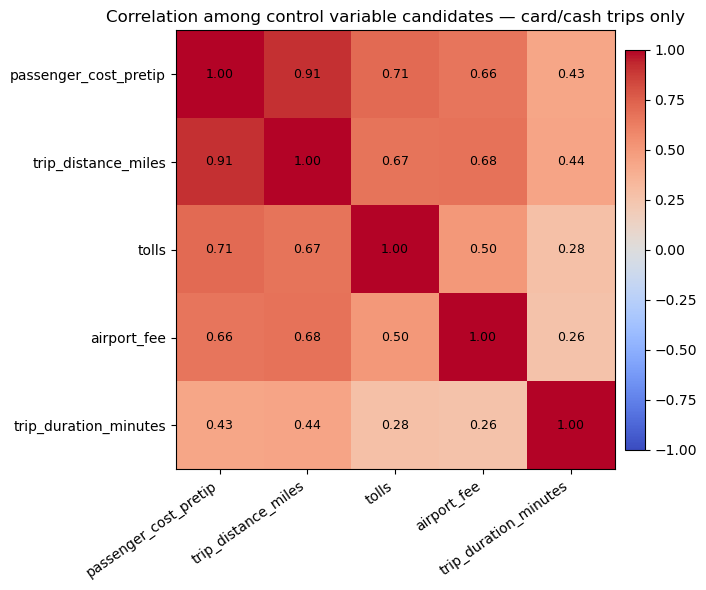

In [44]:
# Correlation heatmap: card/cash trips only.
# Flex Fare excluded (unreliable distance). Mechanically derived variables excluded.
# Focus: which variables are redundant vs independently useful as controls.
general_relationship_vars = [
    "passenger_cost_pretip",
    "trip_distance_miles",
    "trip_duration_seconds",
    "tolls",
    "airport_fee",
]

relationship_df = (
    sample[sample["yellow_card_or_cash_flag"]][general_relationship_vars]
    .dropna()
    .copy()
)
relationship_df["trip_duration_minutes"] = relationship_df.pop("trip_duration_seconds") / 60

corr = relationship_df.corr()

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=35, ha="right")
ax.set_yticklabels(corr.columns)
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=9)
fig.colorbar(im, ax=ax, fraction=0.04, pad=0.02)
ax.set_title("Correlation among control variable candidates — card/cash trips only")
plt.tight_layout()
plt.show()

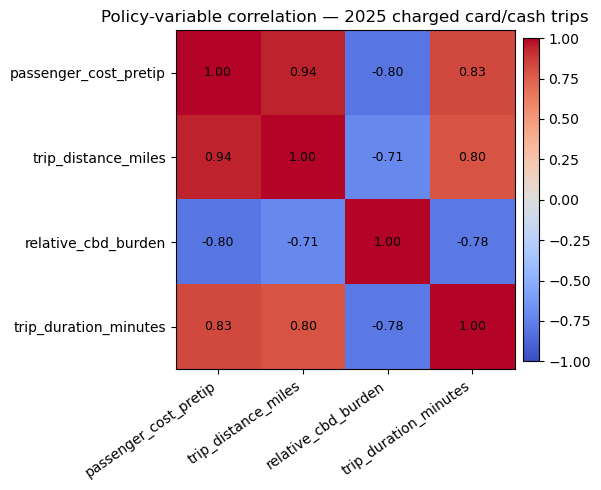

In [45]:
# Policy-variable correlation: 2025 charged card/cash trips only.
# cbd_congestion_fee excluded (near-constant $0.75, Pearson correlation undefined for constants).
# passenger_cost_excl_cbd excluded (mechanically derived from passenger_cost_pretip).
policy_relationship_vars = [
    "passenger_cost_pretip",
    "trip_distance_miles",
    "trip_duration_seconds",
    "relative_cbd_burden",
]

policy_relationship_df = (
    charged_2025[charged_2025["yellow_card_or_cash_flag"]][policy_relationship_vars]
    .dropna()
    .copy()
)
policy_relationship_df["trip_duration_minutes"] = policy_relationship_df.pop("trip_duration_seconds") / 60

corr = policy_relationship_df.corr()

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=35, ha="right")
ax.set_yticklabels(corr.columns)
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=9)
fig.colorbar(im, ax=ax, fraction=0.04, pad=0.02)
ax.set_title("Policy-variable correlation — 2025 charged card/cash trips")
plt.tight_layout()
plt.show()

In [46]:
# Do airport trips tend to be charged the CBD fee?
# Airport fee > 0 indicates a JFK or LGA trip.
# Using all 2025 card/cash trips (not just charged) to get meaningful charged share.
airport_cbd = (
    sample[sample["yellow_card_or_cash_flag"] & (sample["year"] == 2025)]
    .assign(airport_trip=lambda d: d["airport_fee"].fillna(0) > 0)
    .groupby("airport_trip")
    .apply(lambda g: pd.Series({
        "sample_rows": len(g),
        "charged_cbd_share_pct": 100 * g["charged_cbd_flag"].mean(),
        "median_passenger_cost": g["passenger_cost_pretip"].median(),
        "median_distance_miles": g["trip_distance_miles"].median(),
    }))
    .rename(index={False: "Non-airport trip", True: "Airport trip"})
    .reset_index()
    .rename(columns={"airport_trip": "trip_type"})
)

airport_cbd

,trip_type,sample_rows,charged_cbd_share_pct,median_passenger_cost,median_distance_miles
0,Non-airport trip,"7,253.0000",77.8161,17.5500,1.5500
1,Airport trip,691.0000,44.5731,67.4500,11.3400


In [47]:
# JFK vs LGA: charged CBD share and relative burden by airport and direction.
# Zone IDs: JFK = 132, LGA = 138.
# Only airport_fee > 1 rows (confirmed airport trips), 2025 card/cash only.
# Relative burden only meaningful for charged trips.

JFK_ID = 132
LGA_ID = 138

airport_trips = (
    sample[
        sample["yellow_card_or_cash_flag"]
        & (sample["year"] == 2025)
        & (sample["airport_fee"].fillna(0) > 1)
    ].copy()
)

def classify_airport(row):
    pu = row["PULocationID"]
    do = row["DOLocationID"]
    if pu == JFK_ID:
        return "JFK pickup"
    elif do == JFK_ID:
        return "JFK dropoff"
    elif pu == LGA_ID:
        return "LGA pickup"
    elif do == LGA_ID:
        return "LGA dropoff"
    else:
        return "Other"

airport_trips["airport_direction"] = airport_trips.apply(classify_airport, axis=1)

airport_summary = (
    airport_trips[airport_trips["airport_direction"] != "Other"]
    .groupby("airport_direction")
    .apply(lambda g: pd.Series({
        "sample_rows": len(g),
        "charged_cbd_share_pct": 100 * g["charged_cbd_flag"].mean(),
        "median_passenger_cost": g["passenger_cost_pretip"].median(),
        "median_distance_miles": g["trip_distance_miles"].median(),
        "median_relative_burden": g.loc[g["charged_cbd_flag"], "relative_cbd_burden"].median(),
    }))
    .reset_index()
)

airport_summary

,airport_direction,sample_rows,charged_cbd_share_pct,median_passenger_cost,median_distance_miles,median_relative_burden
0,JFK dropoff,5.0000,0.0000,56.0500,12.1100,NaN
1,JFK pickup,382.0000,41.0995,81.5000,17.2850,0.0090
2,LGA dropoff,2.0000,0.0000,72.7000,0.0500,NaN
3,LGA pickup,281.0000,49.1103,58.5400,9.3200,0.0119


In [48]:
airport_fee_rows = sample[
    sample["yellow_card_or_cash_flag"]
    & (sample["year"] == 2025)
    & (sample["airport_fee"].fillna(0) > 0)
].copy()
not_airport_zone = airport_fee_rows[
    ~airport_fee_rows["PULocationID"].isin([JFK_ID, LGA_ID])
    & ~airport_fee_rows["DOLocationID"].isin([JFK_ID, LGA_ID])
]
print(f"Rows with airport_fee > 0: {len(airport_fee_rows)}")
print(f"Rows with airport_fee > 0 but no JFK/LGA zone: {len(not_airport_zone)} ({100*len(not_airport_zone)/len(airport_fee_rows):.1f}%)")
if len(not_airport_zone) > 0:
    display(not_airport_zone[["PULocationID", "DOLocationID", "airport_fee", "trip_distance_miles", "passenger_cost_pretip", "payment_type"]].head(10))
    flex_count = (not_airport_zone["payment_type"] == 0).sum()
    print(f"Of these, Flex Fare (payment_type=0): {flex_count} ({100*flex_count/len(not_airport_zone):.1f}%)")


Rows with airport_fee > 0: 691
Rows with airport_fee > 0 but no JFK/LGA zone: 21 (3.0%)


,PULocationID,DOLocationID,airport_fee,trip_distance_miles,passenger_cost_pretip,payment_type
9320,70,170,1.7500,7.9300,66.4400,1
10018,70,170,1.7500,8.4900,58.2400,1
10429,70,262,1.7500,7.7100,48.9900,1
10879,70,79,1.7500,9.7000,57.8000,1
11746,70,263,1.7500,8.1600,52.1900,1
12886,70,48,1.7500,10.1000,66.2400,2
13418,70,164,1.7500,11.4500,75.3400,1
13792,129,70,1.7500,0.8600,79.6900,1
13946,70,163,1.7500,7.7800,56.5000,1
14696,70,108,1.7500,22.3800,92.7500,2


Of these, Flex Fare (payment_type=0): 0 (0.0%)


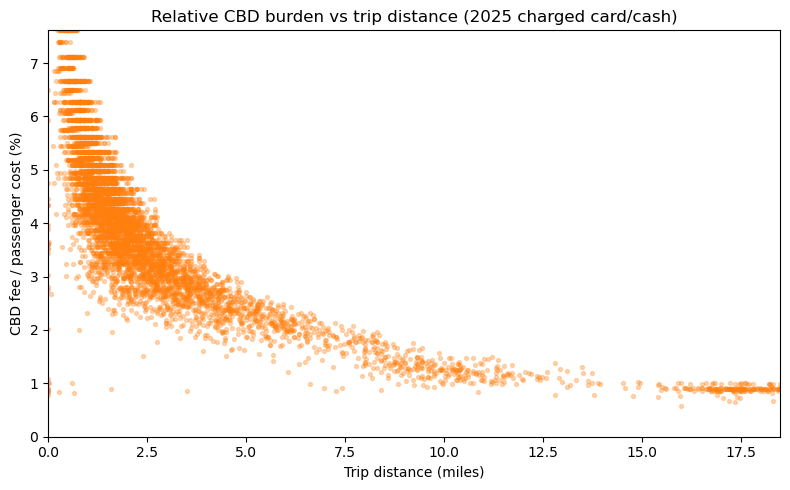

In [49]:
# Relative CBD burden vs trip distance: 2025 charged card/cash trips only.
burden_scatter = sample[
    sample["yellow_card_or_cash_flag"]
    & (sample["year"] == 2025)
    & (sample["charged_cbd_flag"])
].copy()

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(
    burden_scatter["trip_distance_miles"],
    burden_scatter["relative_cbd_burden"] * 100,
    s=8,
    alpha=0.3,
    color="tab:orange",
)
ax.set_xlim(0, burden_scatter["trip_distance_miles"].quantile(0.99))
ax.set_ylim(0, (burden_scatter["relative_cbd_burden"] * 100).quantile(0.99))
ax.set_title("Relative CBD burden vs trip distance (2025 charged card/cash)")
ax.set_xlabel("Trip distance (miles)")
ax.set_ylabel("CBD fee / passenger cost (%)")
plt.tight_layout()
plt.show()

In [50]:
# Binned summaries are often easier to interpret than raw scatter plots.
# CBD exposure/burden summaries use post-policy 2025 trips only.
main_paid_2025 = sample[(sample["yellow_card_or_cash_flag"]) & (sample["year"] == 2025)].copy()
main_paid_2025["distance_bucket"] = pd.cut(
    main_paid_2025["trip_distance_miles"],
    bins=[0, 1, 2, 5, 10, 20, np.inf],
    labels=["(0,1]", "(1,2]", "(2,5]", "(5,10]", "(10,20]", "20+"],
    include_lowest=True,
)
main_paid_2025["cost_bucket"] = pd.cut(
    main_paid_2025["passenger_cost_pretip"],
    bins=[0, 10, 20, 40, 80, np.inf],
    labels=["(0,10]", "(10,20]", "(20,40]", "(40,80]", "80+"],
    include_lowest=True,
)

bucket_summary = (
    main_paid_2025.groupby("distance_bucket", observed=False)
    .apply(lambda g: pd.Series({
        "sample_rows": len(g),
        "weighted_share_pct": 100 * g["sample_weight"].sum() / main_paid_2025["sample_weight"].sum(),
        "median_cost": weighted_quantile(g["passenger_cost_pretip"], g["sample_weight"], [0.5])[0],
        "charged_cbd_share_pct": 100 * weighted_share(g["charged_cbd_flag"], g["sample_weight"]),
        "median_relative_burden_charged_pct": 100 * weighted_quantile(g.loc[g["charged_cbd_flag"], "relative_cbd_burden"], g.loc[g["charged_cbd_flag"], "sample_weight"], [0.5])[0],
    }))
    .reset_index()
)

bucket_summary

,distance_bucket,sample_rows,weighted_share_pct,median_cost,charged_cbd_share_pct,median_relative_burden_charged_pct
0,"(0,1]","2,079.0000",26.1707,12.6500,67.7246,5.6180
1,"(1,2]","2,648.0000",33.3332,16.8500,77.3037,4.3478
2,"(2,5]","1,949.0000",24.5344,23.8500,86.5059,3.1056
3,"(5,10]",634.0000,7.9808,41.3500,70.8201,1.8634
4,"(10,20]",574.0000,7.2256,74.7500,58.7110,0.9202
5,20+,60.0000,0.7553,85.8189,41.6667,0.8988


**Findings from this section**

- Distance and cost buckets are useful feature-engineering candidates because the same $0.75 CBD fee has very different relative burden for short/cheap trips versus long/expensive trips.
- Airport trips (airport_fee > 0) have a substantially lower CBD charged share (44.6%) than non-airport trips (77.8%), consistent with airport routes bypassing the CBD via highways. JFK pickup trips have a lower charged share (41%) than LGA pickup trips (49%), reflecting JFK's more highway-dependent routing. A small share of trips (3%) show airport_fee > 0 without a JFK/LGA zone ID — these are concentrated in zone 70 (East Elmhurst), which borders LGA, and likely reflect taximeter zone boundary recording errors rather than data anomalies requiring exclusion.

## 11. Pre/Post Comparability

Because the project compares pre-policy 2024 trips to post-policy 2025 trips to see the policy influence, we need to check whether the two periods have similar trip composition. If the composition differs, raw before/after averages can be misleading.

This section compares month, payment regime, distance, duration, cost, and temporal composition across 2024 and 2025.

In [51]:
# Comparability check.
# cost/distance/duration: card/cash only (Flex Fare distance unreliable).
# flex_fare_share and disputed_share computed from full sample.
comparability_by_month = (
    sample.groupby(["year", "month"])
    .apply(lambda g: pd.Series({
        "estimated_cleaned_population": g["sample_weight"].sum(),
        "median_cost": weighted_quantile(g.loc[g["yellow_card_or_cash_flag"], "passenger_cost_pretip"], g.loc[g["yellow_card_or_cash_flag"], "sample_weight"], [0.5])[0],
        "median_distance": weighted_quantile(g.loc[g["yellow_card_or_cash_flag"], "trip_distance_miles"], g.loc[g["yellow_card_or_cash_flag"], "sample_weight"], [0.5])[0],
        "median_duration_min": weighted_quantile(g.loc[g["yellow_card_or_cash_flag"], "trip_duration_seconds"] / 60, g.loc[g["yellow_card_or_cash_flag"], "sample_weight"], [0.5])[0],
        "flex_fare_share_pct": 100 * weighted_share(g["flex_fare_flag"], g["sample_weight"]),
        "disputed_share_pct": 100 * weighted_share(g["yellow_disputed_flag"], g["sample_weight"]),
        "charged_cbd_share_pct": 100 * weighted_share(g["charged_cbd_flag"], g["sample_weight"]),
    }))
    .reset_index()
)

comparability_by_month
# disputed = payment_type 3 (No charge), 4 (Dispute), 5 (Unknown), 6 (Voided)

,year,month,estimated_cleaned_population,median_cost,median_distance,median_duration_min,flex_fare_share_pct,disputed_share_pct,charged_cbd_share_pct
0,2024,2,"2,970,277.0000",17.5000,1.6600,11.6667,6.6959,1.3767,0.0000
1,2024,3,"3,536,782.0000",18.2000,1.7200,12.2417,12.5591,1.0510,0.0000
2,2024,4,"3,469,080.0000",18.5000,1.7200,12.5667,11.3551,1.0712,0.0000
3,2024,5,"3,673,319.0000",18.6000,1.7200,12.9667,10.2175,1.3151,0.0000
4,2024,6,"3,488,938.0000",18.2000,1.7000,12.8167,11.9808,1.8637,0.0000
5,2025,2,"3,516,753.0000",18.2500,1.6450,12.1083,22.7801,1.7442,74.4715
6,2025,3,"4,053,697.0000",18.2500,1.7000,11.8500,22.7419,1.8799,73.0399
7,2025,4,"3,862,613.0000",18.2500,1.6000,11.7250,20.4906,1.8759,74.1703
8,2025,5,"4,414,520.0000",19.0000,1.7300,13.0417,27.1044,1.4310,73.6532
9,2025,6,"4,179,498.0000",18.6500,1.6750,12.7333,29.0351,1.6007,72.9658


In [52]:
# Break down disputed trips by payment_type by year.
review_breakdown = (
    sample[sample["yellow_disputed_flag"]]
    .groupby(["year", "payment_type"])["sample_weight"]
    .sum()
    .reset_index(name="weighted_count")
)
review_breakdown["share_within_year_pct"] = (
    100 * review_breakdown["weighted_count"]
    / review_breakdown.groupby("year")["weighted_count"].transform("sum")
)
review_breakdown["payment_type_label"] = review_breakdown["payment_type"].map({
    3: "No charge", 4: "Dispute", 5: "Unknown", 6: "Voided"
})
review_breakdown[["year", "payment_type_label", "weighted_count", "share_within_year_pct"]]

,year,payment_type_label,weighted_count,share_within_year_pct
0,2024,No charge,"55,744.1596",24.3897
1,2024,Dispute,"172,812.4399",75.6103
2,2025,No charge,"94,771.8726",27.8680
3,2025,Dispute,"245,302.4145",72.1320


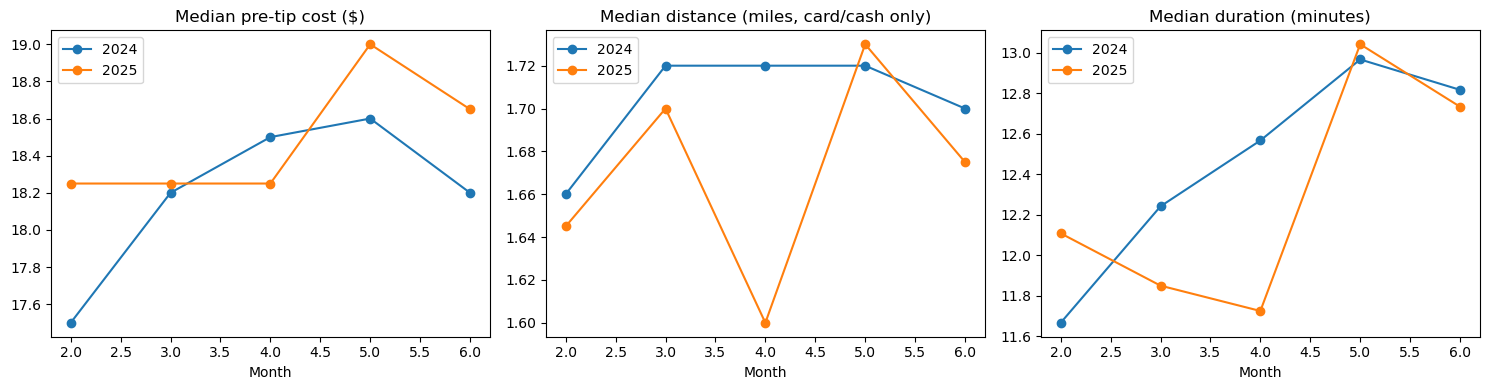

In [53]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
metrics = [
    ("median_cost", "Median pre-tip cost ($)"),
    ("median_distance", "Median distance (miles, card/cash only)"),
    ("median_duration_min", "Median duration (minutes)"),
]

for ax, (col, title) in zip(axes, metrics):
    for year in [2024, 2025]:
        g = comparability_by_month[comparability_by_month["year"] == year]
        ax.plot(g["month"], g[col], marker="o", label=str(year))
    ax.set_title(title)
    ax.set_xlabel("Month")
    ax.legend()

plt.tight_layout()
plt.show()

In [54]:
# Compare temporal composition using weighted shares by pickup hour.
hour_comp = (
    sample.groupby(["year", "pickup_hour"])["sample_weight"]
    .sum()
    .reset_index(name="weighted_count")
)
hour_comp["weighted_share_within_year_pct"] = (
    100 * hour_comp["weighted_count"] / hour_comp.groupby("year")["weighted_count"].transform("sum")
)

hour_pivot = hour_comp.pivot(index="pickup_hour", columns="year", values="weighted_share_within_year_pct").fillna(0)
hour_pivot["diff_2025_minus_2024_pctpt"] = hour_pivot[2025] - hour_pivot[2024]
hour_pivot.head(24)

year,2024,2025,diff_2025_minus_2024_pctpt
pickup_hour,,,
0,2.7215,3.1178,0.3963
1,2.2878,2.1063,-0.1814
2,1.2469,1.4568,0.2099
3,0.9758,0.8444,-0.1314
4,0.6831,0.8258,0.1428
5,0.6397,0.7052,0.0655
6,1.3987,1.3640,-0.0347
7,2.7431,3.0435,0.3003
8,3.7732,3.9900,0.2168


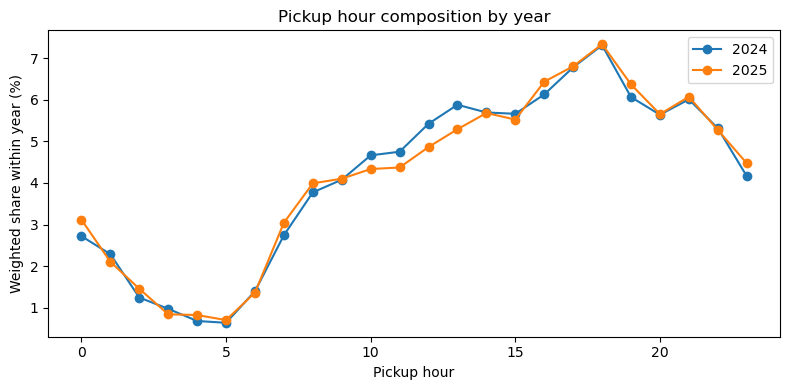

In [55]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(hour_pivot.index, hour_pivot[2024], marker="o", label="2024")
ax.plot(hour_pivot.index, hour_pivot[2025], marker="o", label="2025")
ax.set_title("Pickup hour composition by year")
ax.set_xlabel("Pickup hour")
ax.set_ylabel("Weighted share within year (%)")
ax.legend()
plt.tight_layout()
plt.show()

In [56]:
# Compare day-of-week composition.
dow_comp = (
    sample.groupby(["year", "day_of_week"])["sample_weight"]
    .sum()
    .reset_index(name="weighted_count")
)
dow_comp["weighted_share_within_year_pct"] = (
    100 * dow_comp["weighted_count"] / dow_comp.groupby("year")["weighted_count"].transform("sum")
)
dow_comp["day"] = dow_comp["day_of_week"].map(dict(enumerate(["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"])))

dow_pivot = dow_comp.pivot(index="day", columns="year", values="weighted_share_within_year_pct").reindex(["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"])
dow_pivot["diff_2025_minus_2024_pctpt"] = dow_pivot[2025] - dow_pivot[2024]
dow_pivot

year,2024,2025,diff_2025_minus_2024_pctpt
day,,,
Mon,11.4929,12.2113,0.7184
Tue,13.8890,13.1297,-0.7594
Wed,15.4288,14.2617,-1.1670
Thu,15.2554,15.0133,-0.2421
Fri,14.6808,15.1804,0.4996
Sat,15.6134,16.4147,0.8013
Sun,13.6398,13.7889,0.1491


/var/folders/vt/9yl151q908915k56sck33jp40000gn/T/ipykernel_66824/675174175.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(plot_data, labels=labels, showfliers=False)
/var/folders/vt/9yl151q908915k56sck33jp40000gn/T/ipykernel_66824/675174175.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(plot_data, labels=labels, showfliers=False)
/var/folders/vt/9yl151q908915k56sck33jp40000gn/T/ipykernel_66824/675174175.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(plot_data, labels=labels, showfliers=False)
/var/folders/vt/9yl151q908915k56sck33jp40000gn/T/ipykernel_66824/675174175.p

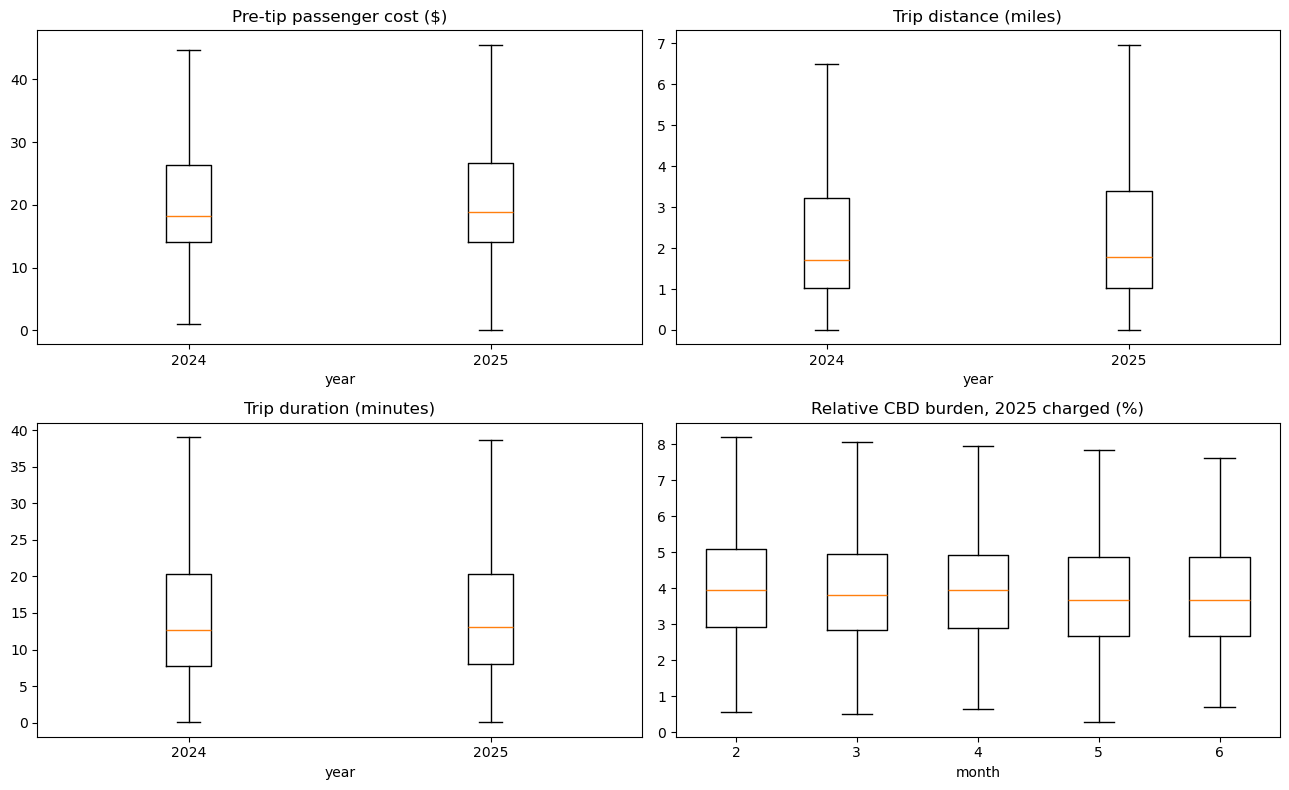

In [57]:
# Boxplots use trimmed plotting ranges so the central distributions are visible.
# The underlying summary tables above still include the full sample.
boxplot_df = sample.copy()
boxplot_df["trip_duration_minutes"] = boxplot_df["trip_duration_seconds"] / 60
charged_boxplot_df = charged_2025.copy()
charged_boxplot_df["relative_cbd_burden_pct"] = 100 * charged_boxplot_df["relative_cbd_burden"]

boxplot_specs = [
    (boxplot_df, "passenger_cost_pretip", "Pre-tip passenger cost ($)", 0.99, "year"),
    (boxplot_df, "trip_distance_miles", "Trip distance (miles)", 0.99, "year"),
    (boxplot_df, "trip_duration_minutes", "Trip duration (minutes)", 0.99, "year"),
    (charged_boxplot_df, "relative_cbd_burden_pct", "Relative CBD burden, 2025 charged (%)", 0.99, "month"),
]

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
for ax, (df_box, col, title, qmax, group_col) in zip(axes.ravel(), boxplot_specs):
    plot_data = []
    labels = []
    upper = df_box[col].quantile(qmax)
    for label, g in df_box[df_box[col] <= upper].groupby(group_col):
        plot_data.append(g[col].dropna())
        labels.append(str(label))
    ax.boxplot(plot_data, labels=labels, showfliers=False)
    ax.set_title(title)
    ax.set_xlabel(group_col)

plt.tight_layout()
plt.show()

**Findings from this section**

- The 2024 and 2025 card/cash trip populations are broadly comparable in composition: pickup hour distribution, day-of-week distribution, and the share of disputed trips (No charge / Dispute, ~75/25 split) are stable across the two years.
- Three features show notable differences between years: (1) median pre-tip cost is slightly higher in 2025 (~$18.2–19.0) than 2024 (~$17.6–18.6); (2) median trip distance in 2025 shows a sharp dip in April (1.60 miles) not seen in 2024; (3) median trip duration patterns cross between years, with 2025 starting lower in February but converging by May. The distance and duration differences are likely sample noise — each year×month card/cash cell contains only ~800–1,000 rows, which is insufficient for stable monthly medians. These patterns should be verified on the full data.
- The cost difference is the most credible year-over-year signal and warrants further investigation in the full-data time series notebook.

## 12. CBD Exposure and Geography

This section explores which trips are more likely to be charged the CBD fee. This is descriptive, not causal. The purpose is to identify geography/time/trip-length features that may be useful later.

Zone IDs are categorical labels, so we summarize top pickup/dropoff zones instead of treating IDs as continuous numeric variables. A next step should merge the TLC taxi zone lookup table to convert IDs into borough and zone names.

In [58]:
charged_2025 = sample[(sample["year"] == 2025) & (sample["charged_cbd_flag"])]
all_2025 = sample[sample["year"] == 2025]

exposure_by_hour = (
    all_2025.groupby("pickup_hour")
    .apply(lambda g: pd.Series({
        "sample_rows": len(g),
        "estimated_trips": g["sample_weight"].sum(),
        "charged_cbd_share_pct": 100 * weighted_share(g["charged_cbd_flag"], g["sample_weight"]),
        "median_relative_burden_charged_pct": 100 * weighted_quantile(g.loc[g["charged_cbd_flag"], "relative_cbd_burden"], g.loc[g["charged_cbd_flag"], "sample_weight"], [0.5])[0],
    }))
    .reset_index()
)

exposure_by_hour.head()

,pickup_hour,sample_rows,estimated_trips,charged_cbd_share_pct,median_relative_burden_charged_pct
0,0,336.0000,"624,396.4485",80.6546,3.7669
1,1,227.0000,"421,840.2613",85.0221,4.2017
2,2,157.0000,"291,760.0476",84.7133,3.8961
3,3,91.0000,"169,111.5403",74.7259,3.9513
4,4,89.0000,"165,391.9079",65.1664,4.0489


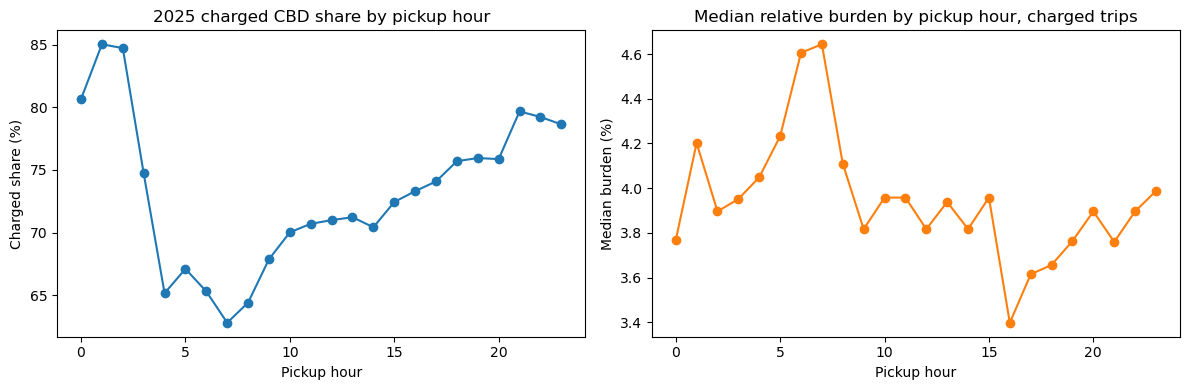

In [59]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(exposure_by_hour["pickup_hour"], exposure_by_hour["charged_cbd_share_pct"], marker="o")
axes[0].set_title("2025 charged CBD share by pickup hour")
axes[0].set_xlabel("Pickup hour")
axes[0].set_ylabel("Charged share (%)")

axes[1].plot(exposure_by_hour["pickup_hour"], exposure_by_hour["median_relative_burden_charged_pct"], marker="o", color="tab:orange")
axes[1].set_title("Median relative burden by pickup hour, charged trips")
axes[1].set_xlabel("Pickup hour")
axes[1].set_ylabel("Median burden (%)")

plt.tight_layout()
plt.show()

In [60]:
exposure_by_distance_bucket = (
    all_2025.assign(
        distance_bucket=pd.cut(
            all_2025["trip_distance_miles"],
            bins=[0, 1, 2, 5, 10, 20, np.inf],
            labels=["(0,1]", "(1,2]", "(2,5]", "(5,10]", "(10,20]", "20+"],
            include_lowest=True,
        )
    )
    .groupby("distance_bucket", observed=False)
    .apply(lambda g: pd.Series({
        "sample_rows": len(g),
        "weighted_share_pct": 100 * g["sample_weight"].sum() / all_2025["sample_weight"].sum(),
        "charged_cbd_share_pct": 100 * weighted_share(g["charged_cbd_flag"], g["sample_weight"]),
        "median_relative_burden_charged_pct": 100 * weighted_quantile(g.loc[g["charged_cbd_flag"], "relative_cbd_burden"], g.loc[g["charged_cbd_flag"], "sample_weight"], [0.5])[0],
    }))
    .reset_index()
)

exposure_by_distance_bucket

,distance_bucket,sample_rows,weighted_share_pct,charged_cbd_share_pct,median_relative_burden_charged_pct
0,"(0,1]","2,633.0000",24.4317,68.4389,5.6180
1,"(1,2]","3,341.0000",31.0011,77.0130,4.3478
2,"(2,5]","2,982.0000",27.6701,81.1536,3.1056
3,"(5,10]","1,065.0000",9.8821,68.4505,1.9815
4,"(10,20]",683.0000,6.3375,55.9299,0.9804
5,20+,73.0000,0.6774,39.7262,0.8988


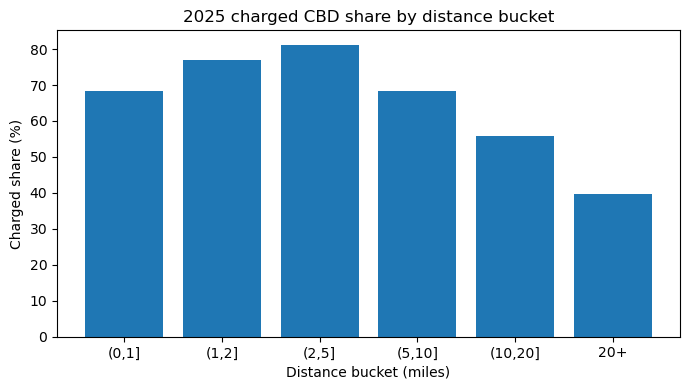

In [61]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(exposure_by_distance_bucket["distance_bucket"].astype(str), exposure_by_distance_bucket["charged_cbd_share_pct"])
ax.set_title("2025 charged CBD share by distance bucket")
ax.set_xlabel("Distance bucket (miles)")
ax.set_ylabel("Charged share (%)")
plt.tight_layout()
plt.show()

In [62]:
# Top origin-destination pairs among charged 2025 trips.
top_od_charged = (
    charged_2025.groupby(["PULocationID", "DOLocationID"])
    .agg(
        estimated_charged_trips=("sample_weight", "sum"),
        sample_rows=("sample_row_id", "count"),
        median_relative_burden=("relative_cbd_burden", "median"),
    )
    .sort_values("estimated_charged_trips", ascending=False)
    .head(20)
    .reset_index()
    .merge(zone_lookup, left_on="PULocationID", right_on="LocationID", how="left")
    .rename(columns={"Borough": "PU_Borough", "Zone": "PU_Zone"})
    .drop(columns=["LocationID"])
    .merge(zone_lookup, left_on="DOLocationID", right_on="LocationID", how="left")
    .rename(columns={"Borough": "DO_Borough", "Zone": "DO_Zone"})
    .drop(columns=["LocationID"])
    [["PU_Borough", "PU_Zone", "PULocationID", "DO_Borough", "DO_Zone", "DOLocationID", "estimated_charged_trips", "sample_rows", "median_relative_burden"]]
)

top_od_charged

,PU_Borough,PU_Zone,PULocationID,DO_Borough,DO_Zone,DOLocationID,estimated_charged_trips,sample_rows,median_relative_burden
0,Manhattan,Midtown Center,161,Manhattan,Upper East Side South,237,"66,902.9807",36,0.0502
1,Manhattan,Upper East Side South,237,Manhattan,Midtown Center,161,"61,318.7439",33,0.0508
2,Queens,JFK Airport,132,Manhattan,Times Sq/Theatre District,230,"48,316.2020",26,0.0090
3,Manhattan,Midtown North,163,Manhattan,Upper East Side North,236,"46,457.2418",25,0.0376
4,Manhattan,Upper East Side South,237,Manhattan,Midtown East,162,"46,455.3977",25,0.0485
5,Manhattan,Midtown North,163,Manhattan,Upper East Side South,237,"46,454.2042",25,0.0464
6,Manhattan,Penn Station/Madison Sq West,186,Manhattan,Times Sq/Theatre District,230,"44,601.5382",24,0.0410
7,Manhattan,Penn Station/Madison Sq West,186,Manhattan,Murray Hill,170,"44,600.0361",24,0.0464
8,Manhattan,Upper East Side North,236,Manhattan,Midtown Center,161,"44,595.4009",24,0.0385
9,Manhattan,Midtown Center,161,Manhattan,Midtown South,164,"42,740.3071",23,0.0523


**Findings from this section**

- CBD charged share by pickup hour shows a counter-intuitive pattern: late night and early morning hours (0–2, 21–23) have the highest charged share (~80–85%), while early morning hours (5–8) have the lowest (~63–67%). The reason for this pattern is not clear from the sample alone and requires validation and further investigation on the full data.
- Median relative burden by pickup hour is relatively stable across the day (~3.8–4.6%), with a local peak around 6–7am and a dip around 16:00. No strong time-of-day gradient is apparent.
- CBD charged share by distance bucket peaks at 2–5 miles (81%) and declines monotonically for longer trips (20+ miles: 40%). Very short trips (0–1 miles, 68%) have a lower charged share than 1–5 mile trips, suggesting they are not always CBD-routed.
- Median relative burden decreases monotonically with distance — from 5.6% for trips under 1 mile to 0.9% for trips over 20 miles — because a fixed $0.75 fee is a larger share of a short, low-cost trip.
- Top OD pairs among charged trips are concentrated within Manhattan, which aligns with expected CBD geography. Zone-level rankings should be treated as directional given small per-zone sample sizes; full-data analysis is needed before drawing conclusions about specific zones or corridors.

## 13. Outliers and Distribution Shape

This section examines the distribution shape and outlier characteristics of key continuous variables. The structure is:
1. Cost distribution comparisons (charged vs not-charged; pre vs post).
2. IQR and robust z-score diagnostics to quantify the extent of skew and extreme values.
3. IsolationForest as a multivariate anomaly check.

Domain-based flags (Flex Fare, zero distance, very long distance) remain the primary data quality rules; the tools here are supporting diagnostics.

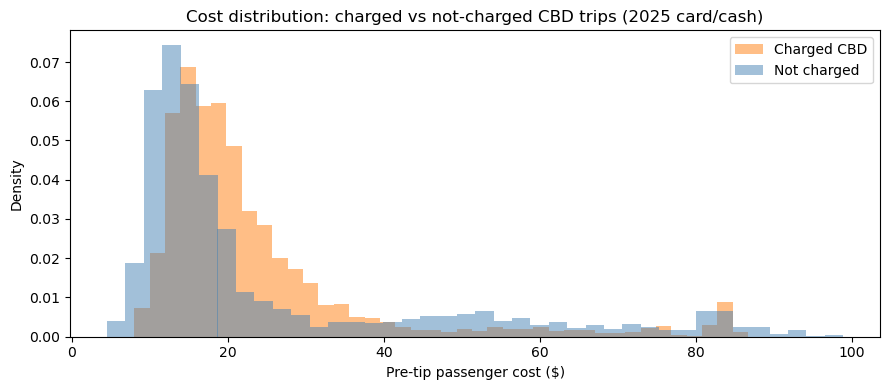

Median cost — charged: 19.25
Median cost — not charged: 15.8


In [63]:
# Cost distribution: charged vs not charged (2025 card/cash only)
fig, ax = plt.subplots(figsize=(9, 4))
for charged, label, color in [(True, "Charged CBD", "tab:orange"), (False, "Not charged", "steelblue")]:
    grp = main_paid_2025[main_paid_2025["charged_cbd_flag"] == charged]["passenger_cost_pretip"]
    grp = grp[grp <= grp.quantile(0.99)]
    ax.hist(grp, bins=40, alpha=0.5, label=label, color=color, density=True)
ax.set_xlabel("Pre-tip passenger cost ($)")
ax.set_ylabel("Density")
ax.set_title("Cost distribution: charged vs not-charged CBD trips (2025 card/cash)")
ax.legend()
plt.tight_layout()
plt.show()

print("Median cost — charged:", main_paid_2025[main_paid_2025["charged_cbd_flag"]]["passenger_cost_pretip"].median())
print("Median cost — not charged:", main_paid_2025[~main_paid_2025["charged_cbd_flag"]]["passenger_cost_pretip"].median())

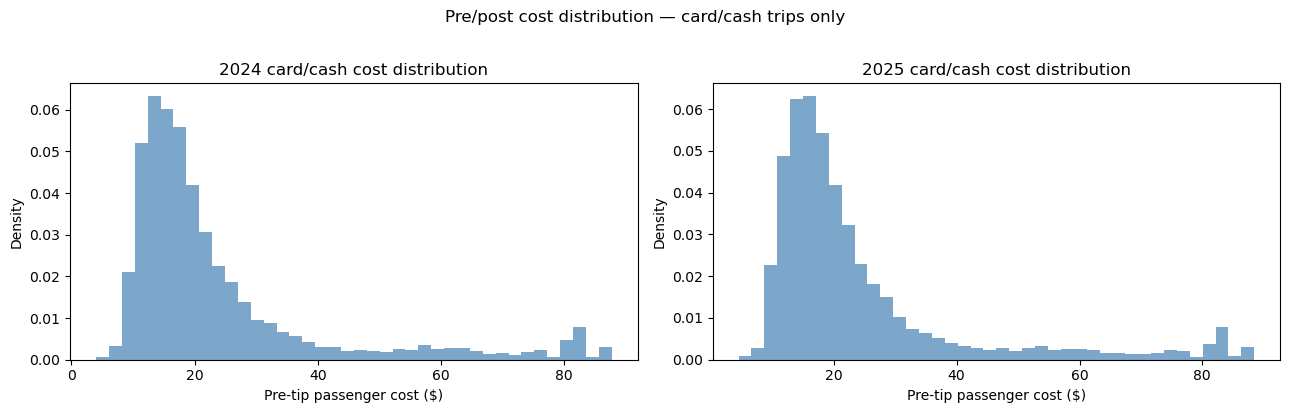

2024 card/cash median cost: $18.20
2025 card/cash median cost: $18.55


In [64]:
# Pre/post cost distribution by regime (card/cash only, same months)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, year in zip(axes, [2024, 2025]):
    grp = sample[sample["yellow_card_or_cash_flag"] & (sample["year"] == year)]["passenger_cost_pretip"]
    grp = grp[grp <= grp.quantile(0.99)]
    ax.hist(grp, bins=40, color="steelblue", alpha=0.7, density=True)
    ax.set_title(f"{year} card/cash cost distribution")
    ax.set_xlabel("Pre-tip passenger cost ($)")
    ax.set_ylabel("Density")

plt.suptitle("Pre/post cost distribution — card/cash trips only", y=1.02)
plt.tight_layout()
plt.show()

for year in [2024, 2025]:
    med = sample[sample["yellow_card_or_cash_flag"] & (sample["year"] == year)]["passenger_cost_pretip"].median()
    print(f"{year} card/cash median cost: ${med:.2f}")

In [65]:
# IQR and robust z-score diagnostics for key continuous variables.
# Robust z-score uses MAD, which is more stable for skewed distributions than mean/std z-score.
outlier_check_df = sample.copy()
outlier_check_df["trip_duration_minutes"] = outlier_check_df["trip_duration_seconds"] / 60
outlier_check_df["speed_mph"] = np.where(
    outlier_check_df["trip_duration_seconds"] > 0,
    outlier_check_df["trip_distance_miles"] / (outlier_check_df["trip_duration_seconds"] / 3600),
    np.nan,
)
outlier_check_df["cost_per_mile"] = np.where(
    outlier_check_df["trip_distance_miles"] > 0,
    outlier_check_df["passenger_cost_pretip"] / outlier_check_df["trip_distance_miles"],
    np.nan,
)
outlier_check_vars = [
    "passenger_cost_pretip",
    "trip_distance_miles",
    "trip_duration_minutes",
    "speed_mph",
    "cost_per_mile",
]

outlier_rows = []
for col in outlier_check_vars:
    x = outlier_check_df[col]
    q1 = x.quantile(0.25)
    q3 = x.quantile(0.75)
    iqr = q3 - q1
    upper_iqr = q3 + 1.5 * iqr
    lower_iqr = q1 - 1.5 * iqr
    iqr_mask = (x < lower_iqr) | (x > upper_iqr)

    median = x.median()
    mad = (x - median).abs().median()
    if mad == 0 or pd.isna(mad):
        robust_z = pd.Series(np.nan, index=x.index)
    else:
        robust_z = 0.6745 * (x - median) / mad
    robust_z_mask = robust_z.abs() > 3.5

    outlier_rows.append({
        "variable": col,
        "iqr_lower": lower_iqr,
        "iqr_upper": upper_iqr,
        "iqr_outlier_rows": int(iqr_mask.fillna(False).sum()),
        "iqr_outlier_weighted_share_pct": 100 * weighted_share(iqr_mask.fillna(False), outlier_check_df["sample_weight"]),
        "robust_z_outlier_rows": int(robust_z_mask.fillna(False).sum()),
        "robust_z_outlier_weighted_share_pct": 100 * weighted_share(robust_z_mask.fillna(False), outlier_check_df["sample_weight"]),
    })

pd.DataFrame(outlier_rows)

,variable,iqr_lower,iqr_upper,iqr_outlier_rows,iqr_outlier_weighted_share_pct,robust_z_outlier_rows,robust_z_outlier_weighted_share_pct
0,passenger_cost_pretip,-5.3750,46.4250,2015,10.0749,1938,9.6899
1,trip_distance_miles,-2.5550,7.0050,2396,11.9799,2529,12.6449
2,trip_duration_minutes,-10.9479,39.5354,1123,5.6149,894,4.4699
3,speed_mph,-1.9287,21.6789,1328,6.6401,1002,5.0100
4,cost_per_mile,-2.8722,23.7541,885,4.4250,608,3.0400


In [66]:
from sklearn.ensemble import IsolationForest

iso_cols = ["passenger_cost_pretip", "trip_distance_miles", "trip_duration_seconds"]
iso_df = sample[iso_cols].dropna()
iso = IsolationForest(contamination=0.05, random_state=42)
iso_scores = iso.fit_predict(iso_df)
n_flagged = (iso_scores == -1).sum()
print(f"IsolationForest flags {n_flagged} rows ({n_flagged/len(iso_df):.1%}) as anomalous (contamination=0.05).")
print("These are used as supporting evidence only, not as automatic deletion rules.")
# Show what the flagged rows look like
sample_iso = sample.loc[iso_df.index].copy()
sample_iso["iso_flag"] = (iso_scores == -1)
print(sample_iso[sample_iso["iso_flag"]][iso_cols].describe())

IsolationForest flags 1000 rows (5.0%) as anomalous (contamination=0.05).
These are used as supporting evidence only, not as automatic deletion rules.
       passenger_cost_pretip  trip_distance_miles  trip_duration_seconds
count             1,000.0000           1,000.0000             1,000.0000
mean                 79.2378             256.7937             3,429.4950
std                  30.9348           4,438.3825             5,390.7282
min                   0.0400               0.0000                 3.0000
25%                  71.8400              12.4850             2,158.7500
50%                  81.6900              17.2700             3,189.0000
75%                  86.6900              19.0350             3,906.5000
max                 401.0000          90,783.7200            86,200.0000


In [67]:
# Inspect a few high-burden 2025 charged records to understand whether they are legitimate low-cost trips or data-quality issues.
high_burden_sample = (
    outlier_check_df[(outlier_check_df["year"] == 2025) & (outlier_check_df["charged_cbd_flag"])]
    .sort_values("relative_cbd_burden", ascending=False)
    [[
        "year",
        "month",
        "pickup_datetime",
        "PULocationID",
        "DOLocationID",
        "payment_type",
        "yellow_payment_type_label",
        "trip_regime",
        "trip_distance_miles",
        "trip_duration_minutes",
        "passenger_cost_pretip",
        "cbd_congestion_fee",
        "relative_cbd_burden",
        "zero_distance_flag",
    ]]
    .head(10)
)

high_burden_sample

,year,month,pickup_datetime,PULocationID,DOLocationID,payment_type,yellow_payment_type_label,trip_regime,trip_distance_miles,trip_duration_minutes,passenger_cost_pretip,cbd_congestion_fee,relative_cbd_burden,zero_distance_flag
15768,2025,5,2025-05-24 00:58:10,249,263,0,Flex Fare,flex_fare,4.9200,21.3333,0.7900,0.7500,0.9494,False
17405,2025,5,2025-05-19 16:33:03,164,137,0,Flex Fare,flex_fare,0.0100,6.3833,0.9600,0.7500,0.7812,False
19763,2025,6,2025-06-26 20:02:51,90,246,0,Flex Fare,flex_fare,0.9600,6.5833,1.0000,0.7500,0.7500,False
15580,2025,5,2025-05-29 23:25:40,50,90,0,Flex Fare,flex_fare,2.1400,11.1667,1.0000,0.7500,0.7500,False
9428,2025,2,2025-02-08 17:06:03,141,229,0,Flex Fare,flex_fare,1.2100,5.0833,1.0000,0.7500,0.7500,False
15039,2025,4,2025-04-03 18:50:05,161,164,0,Flex Fare,flex_fare,0.8300,6.1000,1.0000,0.7500,0.7500,False
13411,2025,4,2025-04-12 17:22:59,232,144,0,Flex Fare,flex_fare,1.0000,9.5667,1.0000,0.7500,0.7500,False
9293,2025,2,2025-02-04 23:16:11,68,170,0,Flex Fare,flex_fare,1.6400,10.8333,1.0000,0.7500,0.7500,False
14655,2025,4,2025-04-10 22:29:18,231,144,0,Flex Fare,flex_fare,0.8600,6.4333,1.0000,0.7500,0.7500,False
10359,2025,2,2025-02-19 22:07:01,246,90,0,Flex Fare,flex_fare,0.8800,6.5333,1.0000,0.7500,0.7500,False


**Findings from this section**

**Cost distribution**
- The passenger_cost_pretip distribution is right-skewed in both 2024 and 2025. The two years show broadly similar distribution shapes, with 2025 slightly shifted higher.
- Among 2025 card/cash trips, charged trips have a higher cost distribution than not-charged trips (median: $19.25 vs $15.80), a gap of $3.45 that far exceeds the $0.75 CBD fee itself. This suggests that charged trips tend to be more expensive trips regardless of the fee. This pattern should be validated on the full data; the underlying reason should be examined in the final conclusions chapter.

**Outlier diagnostics**
- IQR and robust z-score diagnostics confirm that cost, distance, duration, and speed are right-skewed with a meaningful tail. Central tendency should be summarized with medians and percentiles rather than means.
- IsolationForest (contamination=5%) flags 1,000 rows (5%). The flagged rows have a median cost of $81.69 and include trips with trip_distance_miles up to 90,783 — driven by Flex Fare garbage distance values already identified in Section 7. The remaining flagged rows are high-cost legitimate trips (e.g. airport trips). IsolationForest does not provide additional signal beyond existing domain-based flags and should not be used as a drop rule here.
- High relative burden records are concentrated among low-cost trips where the fixed $0.75 fee represents a large share of the fare — consistent with legitimate short trips, not data errors.

**Outlier findings from earlier chapters (consolidated)**
- *Section 6 (CBD Fee)*: relative_cbd_burden is right-skewed with extreme values when the trip cost denominator is very small. The p99 cutoff is 0.25 (25%). Winsorization or median-based summaries should be used; extreme rows should not be dropped as they represent real short/cheap trips.
- *Section 7 (Cost/Distance/Duration)*: Three Flex Fare trips have trip_distance_miles of 67,000-90,000 miles — clearly garbage values from the taximeter bypass. Flex Fare distance is unreliable as a feature and should not be used in modeling.
- *Section 5 (Cost Components)*: Zero-distance trips fall into two categories — PU!=DO (real trips with recording errors, keep flagged) and PU==DO (likely cancelled/voided, drop). Component-total mismatches are concentrated in Flex Fare rows due to structural missingness.
- *Section 10 (Relationships)*: Airport trips with airport_fee>0 but no JFK/LGA zone ID (3% of airport trips) are concentrated in zone 70 (East Elmhurst). Exclude from airport-specific analysis but retain as valid trips in the general sample.

## 14. Decisions and Pending Validations

This section consolidates EDA findings into two parts:
1. **Data processing decisions** — rules and flag choices confirmed by the EDA, to be carried into the next analysis stage.
2. **Pending full-data validations** — patterns observed in the 20K sample that require verification on the full cleaned dataset before being interpreted as real signals.

In [68]:
main_analysis_mask = (
    sample["yellow_card_or_cash_flag"]
    & (sample["passenger_cost_pretip"] > 0)
    & (sample["cbd_congestion_fee"] >= 0)
    & (sample["trip_duration_seconds"] > 0)
)

main_subset_summary = pd.Series({
    "all_sample_rows": len(sample),
    "main_analysis_rows_card_or_cash": int(main_analysis_mask.sum()),
    "main_analysis_row_share_pct_unweighted": 100 * main_analysis_mask.mean(),
    "main_analysis_share_pct_weighted": 100 * weighted_share(main_analysis_mask, sample["sample_weight"]),
    "flex_fare_share_pct_weighted": 100 * weighted_share(sample["flex_fare_flag"], sample["sample_weight"]),
    "payment_review_share_pct_weighted": 100 * weighted_share(sample["yellow_payment_review_flag"], sample["sample_weight"]),
})

main_subset_summary.to_frame("value")

,value
all_sample_rows,"20,000.0000"
main_analysis_rows_card_or_cash,"16,059.0000"
main_analysis_row_share_pct_unweighted,80.2950
main_analysis_share_pct_weighted,80.2949
flex_fare_share_pct_weighted,18.1751
payment_review_share_pct_weighted,19.7051


**Data processing decisions**

*Study design*
- Use February-June 2024 as the pre-policy window and February-June 2025 as the post-policy window. January 2025 remains excluded (policy began January 5, transition month).
- Report outcomes by month rather than pooled year averages to avoid mixing pre/post periods.

*Payment regime*
- Main burden analysis: card/cash trips only (payment_type 1 and 2).
- Flex Fare (payment_type 0) must be analyzed separately; its trip_distance_miles is unreliable (taximeter bypass) and must not be used in distance-based modeling. total_amount is reliable for broad cost/volume summaries only.
- No charge, Dispute, Unknown, and Voided trips (payment_type 3/4/5/6) should be excluded from primary analysis and used only for sensitivity checks.

*Core metrics*
- Main cost metric: passenger_cost_pretip = total_amount - tip_amount.
- Main burden metric: relative_cbd_burden = cbd_congestion_fee / passenger_cost_pretip, computed only for 2025 charged card/cash trips. Use median, not mean; winsorize at p99 (0.25) where needed.

*Trip-level cleaning*
- Zero-distance trips: retain PU!=DO rows flagged in broad sample but exclude from distance/speed/per-mile analyses. Consider dropping PU==DO rows from burden analysis (likely cancelled trips).
- Airport trips: rows with airport_fee>0 but PU/DO not in JFK (132) or LGA (138) zones (~3%) are zone boundary recording errors. Exclude from airport-specific analysis but retain as valid trips in the general sample.

*Geography*
- Always merge taxi zone lookup before making geography-facing claims.
- Zone-level and OD-corridor rankings should use the full cleaned dataset, not the 20K sample.

---

**Pending full-data validations**

- *CBD charging by pickup hour* (Section 12): Deep night hours (0-2, 21-23) show highest charged share (~80-85%), early morning (5-8) the lowest (~63-67%). Pattern is counter-intuitive and reason is unclear; requires full-data investigation.
- *Monthly distance and duration patterns* (Section 11): April 2025 shows a sharp distance dip and duration patterns cross between years. Likely sample noise (~800-1,000 card/cash rows per year x month cell); verify on full data.
- *Year-over-year cost difference* (Section 11): 2025 median cost slightly higher than 2024 (~$18.2-19.0 vs ~$17.6-18.6). Most credible year-over-year signal from the sample; quantify on full data.
- *Charged vs not-charged cost gap* (Section 13): Charged trips have a median cost $3.45 higher than not-charged, far exceeding the $0.75 CBD fee. Suggests charged trips are intrinsically more expensive; reason should be examined on full data.
- *Flex Fare CBD charged share time patterns* (Section 8): Sample showed Flex Fare charged share lower on weekends, but full-data validation reversed this finding. Sample is too small for reliable Flex Fare subgroup hourly/DOW analysis.
- *Zone and OD corridor rankings* (Section 9, 12): Directionally consistent with expected Manhattan CBD geography, but per-zone sample sizes are too small for stable rankings. Full-data analysis required.